In [2]:
import pandas as pd
path = '/Volumes/Lexar/mean_reversion_data/signal_scan_results/SOL_USDC/signal_scan_combined.csv'
df = pd.read_csv(path)

KeyboardInterrupt: 

In [ ]:
df

,trade_source,trades_per_bar,bar_duration_sec,factor,factor_window,type,window,threshold,ic,rank_ic,...,short_frac,flat_frac,n_eval_bars,upper_q,lower_q,fast_window,slow_window,lookback,n_std,abs_ic_ir
0,merged,6000,4299.3,off_top_volume_delta_imbalance,8,zscore,5.0,2.0,-0.079605,-0.083048,...,0.000,1.000,503,NaN,NaN,NaN,NaN,NaN,NaN,1.3684
1,merged,6000,4299.3,off_top_volume_delta_imbalance,3,zscore,10.0,1.0,-0.079605,-0.083048,...,0.123,0.742,503,NaN,NaN,NaN,NaN,NaN,NaN,1.3684
2,merged,6000,4299.3,off_top_volume_delta_imbalance,8,rank,5.0,NaN,-0.079605,-0.083048,...,0.000,0.817,503,NaN,NaN,NaN,NaN,NaN,NaN,1.3684
3,merged,6000,4299.3,off_top_volume_delta_imbalance,8,ma_cross,NaN,NaN,-0.079605,-0.083048,...,0.505,0.006,503,NaN,NaN,3.0,10.0,NaN,NaN,1.3684
4,merged,6000,4299.3,off_top_volume_delta_imbalance,8,ma_cross,NaN,NaN,-0.079605,-0.083048,...,0.493,0.004,503,NaN,NaN,2.0,5.0,NaN,NaN,1.3684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12571,merged,2000,1391.2,off_top_volume_imbalance,5,zscore,30.0,2.0,0.026477,0.011521,...,0.034,0.921,1513,NaN,NaN,NaN,NaN,NaN,NaN,0.0013
12572,merged,2000,1391.2,off_top_volume_imbalance,5,zscore,30.0,1.5,0.026477,0.011521,...,0.081,0.822,1513,NaN,NaN,NaN,NaN,NaN,NaN,0.0013
12573,merged,2000,1391.2,off_top_volume_imbalance,5,zscore,30.0,1.0,0.026477,0.011521,...,0.190,0.613,1513,NaN,NaN,NaN,NaN,NaN,NaN,0.0013
12574,merged,2000,1391.2,off_top_volume_imbalance,5,zscore,20.0,2.0,0.026477,0.011521,...,0.034,0.930,1513,NaN,NaN,NaN,NaN,NaN,NaN,0.0013


In [ ]:
df.columns

Index(['trade_source', 'trades_per_bar', 'bar_duration_sec', 'factor',
       'factor_window', 'type', 'window', 'threshold', 'ic', 'rank_ic',
       'ic_mean', 'ic_ir', 'triple_acc', 'hit_long', 'hit_short',
       'long_ret_bps', 'short_ret_bps', 'signal_auto', 'change_rate',
       'avg_duration', 'long_frac', 'short_frac', 'flat_frac', 'n_eval_bars',
       'upper_q', 'lower_q', 'fast_window', 'slow_window', 'lookback', 'n_std',
       'abs_ic_ir'],
      dtype='object')

关注 ic, icir 绝对值的大小 => 区分正反信号因子；并且对 hit rate 进行取反操作

In [33]:
df['abs_ic'] = df['ic'].abs()
df['abs_ic_ir'] = df['ic_ir'].abs()


In [34]:
tpb_2000 = df[df['trades_per_bar'] == 2000]
tpb_6000 = df[df['trades_per_bar'] == 6000]
factor_table_2000 = tpb_2000.groupby('factor')[['ic', 'abs_ic', 'ic_ir', 'abs_ic_ir']].last().reset_index()
factor_table_2000 = factor_table_2000.sort_values('abs_ic_ir', ascending=False)
factor_table_2000

,factor,ic,abs_ic,ic_ir,abs_ic_ir
5,off_top_volume_delta_imbalance,-0.036827,0.036827,-0.3223,0.3223
3,multi_fill_count_imbalance,-0.005298,0.005298,-0.3209,0.3209
19,vwap_dist_sum_imbalance,0.004361,0.004361,-0.2469,0.2469
17,vwap_dist_reg_imbalance,0.008117,0.008117,-0.2362,0.2362
8,price_range_reg_imbalance,0.004921,0.004921,-0.1857,0.1857
13,volume_asymmetry,-0.000549,0.000549,-0.1400,0.1400
15,volume_skew_imbalance,0.027853,0.027853,0.1356,0.1356
7,price_impact,0.005380,0.005380,0.0953,0.0953
16,volume_zscore,0.008195,0.008195,0.0908,0.0908
18,vwap_dist_sum_delta_imbalance,-0.005001,0.005001,0.0868,0.0868


In [35]:
import numpy as np
pos_factor_table_2000 = factor_table_2000[factor_table_2000['ic'] > 0]
neg_factor_table_2000 = factor_table_2000[factor_table_2000['ic'] < 0]
pos_factors_2000 = np.unique(pos_factor_table_2000['factor'])
neg_factors_2000 = np.unique(neg_factor_table_2000['factor'])
print('pos_factors: ', pos_factors_2000)
print('neg_factors: ', neg_factors_2000)


pos_factors:  ['buy_sell_ratio' 'mf_vol_median_ratio_imbalance'
 'multi_fill_volume_imbalance' 'off_top_volume_imbalance' 'price_impact'
 'price_range_reg_imbalance' 'taker_vol_skew' 'trade_imbalance'
 'volume_acceleration' 'volume_autocorr_imbalance' 'volume_skew_imbalance'
 'volume_zscore' 'vwap_dist_reg_imbalance' 'vwap_dist_sum_imbalance'
 'weighted_vwap_dist_sum']
neg_factors:  ['kyles_lambda' 'multi_fill_count_imbalance'
 'off_top_volume_delta_imbalance' 'taker_vol_corr' 'volume_asymmetry'
 'vwap_dist_sum_delta_imbalance']


In [36]:
factor_table_6000 = tpb_6000.groupby('factor')[['ic', 'abs_ic', 'ic_ir', 'abs_ic_ir']].last().reset_index()
factor_table_6000 = factor_table_6000.sort_values('abs_ic_ir', ascending=False)
factor_table_6000

,factor,ic,abs_ic,ic_ir,abs_ic_ir
5,off_top_volume_delta_imbalance,-0.079605,0.079605,-1.3684,1.3684
16,vwap_dist_sum_delta_imbalance,-0.088082,0.088082,-1.0188,1.0188
7,price_impact,-0.019251,0.019251,-0.3869,0.3869
1,kyles_lambda,-0.022007,0.022007,-0.3424,0.3424
12,volume_autocorr_imbalance,-0.004284,0.004284,-0.1795,0.1795
8,price_range_reg_imbalance,0.008459,0.008459,0.1536,0.1536
13,volume_skew_imbalance,0.001194,0.001194,-0.1171,0.1171
10,volume_acceleration,-0.005293,0.005293,-0.1125,0.1125
4,multi_fill_volume_imbalance,0.019671,0.019671,0.1101,0.1101
11,volume_asymmetry,0.017611,0.017611,0.1100,0.1100


In [37]:
pos_factor_table_6000 = factor_table_6000[factor_table_6000['ic'] > 0]
neg_factor_table_6000 = factor_table_6000[factor_table_6000['ic'] < 0]
pos_factors_6000 = np.unique(pos_factor_table_6000['factor'])
neg_factors_6000 = np.unique(neg_factor_table_6000['factor'])
print('pos_factors: ', pos_factors_6000)
print('neg_factors: ', neg_factors_6000)

pos_factors:  ['buy_sell_ratio' 'mf_vol_median_ratio_imbalance'
 'multi_fill_volume_imbalance' 'off_top_volume_imbalance'
 'price_range_reg_imbalance' 'trade_imbalance' 'volume_asymmetry'
 'volume_skew_imbalance' 'vwap_dist_reg_imbalance']
neg_factors:  ['kyles_lambda' 'multi_fill_count_imbalance'
 'off_top_volume_delta_imbalance' 'price_impact' 'volume_acceleration'
 'volume_autocorr_imbalance' 'volume_zscore'
 'vwap_dist_sum_delta_imbalance' 'vwap_dist_sum_imbalance'
 'weighted_vwap_dist_sum']


In [38]:
# check direction of factors in 2000 and 6000
factors = np.unique(df['factor'])
res = []
for f in factors:
    res.append({
        'factor': f,
        'is_pos_2000': f in pos_factors_2000,
        'is_pos_6000': f in pos_factors_6000,
    })
res = pd.DataFrame(res)
res


,factor,is_pos_2000,is_pos_6000
0,buy_sell_ratio,True,True
1,kyles_lambda,False,False
2,mf_vol_median_ratio_imbalance,True,True
3,multi_fill_count_imbalance,False,False
4,multi_fill_volume_imbalance,True,True
5,off_top_volume_delta_imbalance,False,False
6,off_top_volume_imbalance,True,True
7,price_impact,True,False
8,price_range_reg_imbalance,True,True
9,taker_vol_corr,False,False


In [39]:
discrepancy_factor_table = res[res['is_pos_2000'] != res['is_pos_6000']]
discrepancy_factor_table

,factor,is_pos_2000,is_pos_6000
7,price_impact,True,False
10,taker_vol_skew,True,False
12,volume_acceleration,True,False
13,volume_asymmetry,False,True
14,volume_autocorr_imbalance,True,False
16,volume_zscore,True,False
19,vwap_dist_sum_imbalance,True,False
20,weighted_vwap_dist_sum,True,False


In [41]:
high_acc = df[df['triple_acc'] > 0.5]
high_acc = high_acc.sort_values('triple_acc', ascending=False)


,trade_source,trades_per_bar,bar_duration_sec,factor,factor_window,type,window,threshold,ic,rank_ic,...,flat_frac,n_eval_bars,upper_q,lower_q,fast_window,slow_window,lookback,n_std,abs_ic_ir,abs_ic
3008,raw,2000,979.0,volume_zscore,5,zscore,20.0,2.0,0.029664,0.044268,...,0.996,2037,NaN,NaN,NaN,NaN,NaN,NaN,0.3314,0.029664
3001,raw,2000,979.0,volume_zscore,5,zscore,30.0,2.0,0.029664,0.044268,...,0.997,2037,NaN,NaN,NaN,NaN,NaN,NaN,0.3314,0.029664
120,merged,6000,4299.3,volume_autocorr_imbalance,8,bollinger,5.0,NaN,-0.058059,-0.085993,...,0.996,499,NaN,NaN,NaN,NaN,NaN,2.0,1.1048,0.058059
374,merged,6000,4299.3,price_impact,8,bollinger,10.0,NaN,-0.055427,-0.077972,...,0.972,504,NaN,NaN,NaN,NaN,NaN,2.0,0.7163,0.055427
426,merged,6000,4299.3,price_impact,3,bollinger,10.0,NaN,-0.055427,-0.077972,...,0.972,504,NaN,NaN,NaN,NaN,NaN,2.0,0.7163,0.055427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11211,merged,150,93.8,price_impact,20,zscore,40.0,1.0,0.005540,-0.005948,...,0.720,20216,NaN,NaN,NaN,NaN,NaN,NaN,0.0270,0.005540
8403,merged,150,93.8,taker_vol_skew,20,ma_cross,NaN,NaN,-0.005663,-0.004065,...,0.001,20207,NaN,NaN,10.0,60.0,NaN,NaN,0.0613,0.005663
8448,raw,500,230.5,taker_vol_skew,10,ma_cross,NaN,NaN,0.004867,0.001972,...,0.000,8161,NaN,NaN,3.0,10.0,NaN,NaN,0.0588,0.004867
10267,raw,150,64.7,volume_zscore,5,quantile,120.0,NaN,0.002008,0.002536,...,0.602,27233,0.8,0.2,NaN,NaN,NaN,NaN,0.0379,0.002008


In [42]:
high_acc.to_csv('high_acc.csv', index=False)

关注正反方向 acc 不平衡

In [1]:
from __future__ import annotations

import logging
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
from scipy import stats
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from rule_backtest.signals import SIGNAL_CLASSES, BaseSignal
from rule_backtest.data_loader import (
    load_cached_trades,
    merge_aggtrades,
    build_bars,
    compute_factor,
    estimate_avg_bar_seconds,
    RAW_FACTOR_REGISTRY,
    MERGED_FACTOR_REGISTRY,
)

logger = logging.getLogger(__name__)

In [2]:
cache_dir = Path("/Volumes/Lexar/mean_reversion_data/cache")

In [4]:
symbol='SOL/USDC'
cache_subdir: str = "trades_perp"
sym_dir = cache_dir / symbol.replace("/", "_") / cache_subdir
if not sym_dir.exists():
    raise FileNotFoundError(f"Cache directory not found: {sym_dir}")

files = sorted(f for f in sym_dir.glob("*.parquet") if not f.name.startswith("._"))
if not files:
    raise FileNotFoundError(f"No parquet files in {sym_dir}")

logger.info("Loading %d cached files from %s", len(files), sym_dir)
dfs = [pd.read_parquet(f) for f in files]
trades = pd.concat(dfs, ignore_index=True)
trades["timestamp"] = pd.to_datetime(trades["timestamp"])
trades.sort_values("timestamp", inplace=True)
trades.reset_index(drop=True, inplace=True)

# Unified column names
trades.rename(columns={"amount": "volume", "cost": "value"}, inplace=True)

logger.info("Loaded %d trades, %s → %s",
            len(trades), trades["timestamp"].iloc[0], trades["timestamp"].iloc[-1])

In [5]:
trades_df = merge_aggtrades(trades)
trades_df.head()

,timestamp,volume,side,value,n_fills,n_raw_trades,first_price,last_price,first_trade_id,last_trade_id,price,price_range
0,2026-02-02 16:00:01.690000+00:00,16.45,sell,1720.3798,2,7,104.59,104.58,304094557,304094563,104.582359,0.01
1,2026-02-02 16:00:01.843000+00:00,40.10,buy,4193.8513,2,3,104.58,104.59,304094564,304094566,104.584820,0.01
2,2026-02-02 16:00:01.970000+00:00,62.43,sell,6528.9294,1,3,104.58,104.58,304094567,304094569,104.580000,0.00
3,2026-02-02 16:00:02.100000+00:00,5.02,sell,525.0418,1,3,104.59,104.59,304094570,304094572,104.590000,0.00
4,2026-02-02 16:00:02.360000+00:00,0.06,buy,6.2754,1,1,104.59,104.59,304094573,304094573,104.590000,0.00


In [6]:
bar_mode = "trade_count"
bars = build_bars(trades_df, "merged", bar_mode, 500)
bar_sec = int(estimate_avg_bar_seconds(bars))
logger.info("Built %d trade-count bars (%d trades/bar, ~%ds avg)",
            len(bars), 500, bar_sec)

In [7]:
bars

,open,high,low,close,volume,n_trades,buy_volume,sell_volume,buy_trade_count,sell_trade_count,...,buy_mf_vol_median_ratio,sell_mf_vol_median_ratio,buy_vwap_dist_reg_beta,sell_vwap_dist_reg_beta,buy_pr_reg_beta,sell_pr_reg_beta,buy_volume_skew,sell_volume_skew,weighted_vwap_dist,bar_duration_sec
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-02-02 16:00:01.690,104.582359,104.590000,104.38,104.470000,5398.11,200,3112.02,2286.09,102,98,...,-0.835453,-1.419416,0.000401,0.001406,0.001324,0.002367,2.731606,4.052468,-8.1451,78.893
2026-02-02 16:01:21.081,104.479890,104.610000,104.40,104.570000,6154.29,200,3111.91,3042.38,99,101,...,-1.386190,-1.993089,0.000931,0.000774,0.001382,0.001438,3.968450,2.592667,18.7271,94.950
2026-02-02 16:02:56.502,104.574022,104.590000,104.35,104.410000,9101.02,200,2751.99,6349.03,90,110,...,-0.831131,-1.212047,0.000762,0.000673,0.001464,0.001140,3.025289,4.481283,-7.1579,99.812
2026-02-02 16:04:36.466,104.420000,104.460000,104.17,104.460000,9769.26,200,4654.26,5115.00,90,110,...,-0.849369,-1.705203,0.000965,0.001114,0.002026,0.001963,7.378304,7.604990,-60.9893,79.668
2026-02-02 16:05:56.828,104.470000,104.740000,104.43,104.740000,5534.80,200,2683.71,2851.09,89,111,...,-0.459037,-2.049292,0.000756,0.000547,0.001226,0.000997,2.824415,2.596306,4.5561,80.414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-04 15:54:13.391,92.540000,92.560000,92.40,92.470000,6272.20,200,2662.22,3609.98,98,102,...,-1.679411,-1.906466,0.000953,0.000366,0.001366,0.000836,3.019161,7.743905,14.2497,89.067
2026-03-04 15:55:42.573,92.479479,92.610000,92.32,92.590000,6497.63,200,3438.13,3059.50,113,87,...,-0.419143,-1.953313,0.000312,0.000888,0.000459,0.001478,2.986988,4.876661,-9.4826,115.505
2026-03-04 15:57:39.695,92.582723,92.982745,92.55,92.799964,15382.10,200,10561.17,4820.93,110,90,...,-1.797607,-1.465275,0.002118,0.000738,0.004233,0.001727,7.045531,3.618333,175.8797,29.512


In [74]:
bars['vwap_dist_sum_imbalance'] = (bars['buy_vwap_dist_sum'] - bars['sell_vwap_dist_sum']) / (bars['buy_vwap_dist_sum'] + bars['sell_vwap_dist_sum'] + 1e-10)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = bars.copy()

close = df["close"]
factor_name = "vwap_dist_sum_imbalance"
factor = df[factor_name] if factor_name in df.columns else None

# Use bar index for x-axis (works for both time and trade-count bars)
x = df.index

n_rows = 2 
row_heights = [0.7, 0.3]
subplot_titles = ["Price", "Factor"]

fig = make_subplots(
    rows=n_rows, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    row_heights=row_heights,
    subplot_titles=subplot_titles,
)

# Row 1: Price line
fig.add_trace(go.Scatter(
    x=x, y=close.values, mode="lines", name="Price",
    line=dict(color="#1f77b4", width=1.2),
), row=1, col=1)


# Row 3: Factor with SMA / EMA overlays
if factor is not None:
    fig.add_trace(go.Scatter(
        x=x, y=factor.values, mode="lines", name="Factor",
        line=dict(color="#9b59b6", width=0.8),
    ), row=n_rows, col=1)

    sma_w = [3, 5, 10, 30]
    ema_w = [3, 5, 10, 30]
    for w in sma_w: 
        sma = factor.rolling(w, min_periods=1).mean()
        fig.add_trace(go.Scatter(
            x=x, y=sma.values, mode="lines",
            name=f"SMA({w})",
            line=dict(color="#e67e22", width=1.0),
        ), row=n_rows, col=1)
    for w in ema_w:
        ema = factor.ewm(span=w, min_periods=1).mean()
        fig.add_trace(go.Scatter(
            x=x, y=ema.values, mode="lines",
            name=f"EMA({w})",
            line=dict(color="#2ecc71", width=1.0),
        ), row=n_rows, col=1)

fig.update_layout(
    title=dict(
        text=(f"{factor_name}"),
        font=dict(size=14),
    ),
    height=800,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=60, r=30, t=80, b=40),
)

# Enable x-axis range slider on the bottom subplot for scrolling
fig.update_xaxes(rangeslider=dict(visible=True, thickness=0.05), row=n_rows, col=1)
fig.update_xaxes(showticklabels=True, row=1, col=1)

output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
os.makedirs(output_dir / factor_name, exist_ok=True)
html_path = output_dir / factor_name / "price_position_interactive.html"
fig.write_html(str(html_path), include_plotlyjs="cdn")

In [78]:
bars['buy_vwap_dist_sum_fw3'] = bars['buy_vwap_dist_sum'].rolling(3).mean()
bars['sell_vwap_dist_sum_fw3'] = bars['sell_vwap_dist_sum'].rolling(3).mean()
bars['vwap_dist_sum_imbalance_fw3'] = (bars['buy_vwap_dist_sum_fw3'] - bars['sell_vwap_dist_sum_fw3']) / (bars['buy_vwap_dist_sum_fw3'] + bars['sell_vwap_dist_sum_fw3'] + 1e-10)

df = bars.copy()

close = df["close"]
factor_name = "vwap_dist_sum_imbalance_fw3"
factor = df[factor_name] if factor_name in df.columns else None

# Use bar index for x-axis (works for both time and trade-count bars)
x = df.index

n_rows = 2 
row_heights = [0.7, 0.3]
subplot_titles = ["Price", "Factor"]

fig = make_subplots(
    rows=n_rows, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    row_heights=row_heights,
    subplot_titles=subplot_titles,
)

# Row 1: Price line
fig.add_trace(go.Scatter(
    x=x, y=close.values, mode="lines", name="Price",
    line=dict(color="#1f77b4", width=1.2),
), row=1, col=1)


# Row 3: Factor with SMA / EMA overlays
if factor is not None:
    fig.add_trace(go.Scatter(
        x=x, y=factor.values, mode="lines", name="Factor",
        line=dict(color="#9b59b6", width=0.8),
    ), row=n_rows, col=1)

    sma_w = [5, 10, 30]
    ema_w = [5, 10, 30]
    for w in sma_w: 
        sma = factor.rolling(w, min_periods=1).mean()
        fig.add_trace(go.Scatter(
            x=x, y=sma.values, mode="lines",
            name=f"SMA({w})",
            line=dict(color="#e67e22", width=1.0),
        ), row=n_rows, col=1)
    for w in ema_w:
        ema = factor.ewm(span=w, min_periods=1).mean()
        fig.add_trace(go.Scatter(
            x=x, y=ema.values, mode="lines",
            name=f"EMA({w})",
            line=dict(color="#2ecc71", width=1.0),
        ), row=n_rows, col=1)

fig.update_layout(
    title=dict(
        text=(f"{factor_name}"),
        font=dict(size=14),
    ),
    height=800,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=60, r=30, t=80, b=40),
)

# Enable x-axis range slider on the bottom subplot for scrolling
fig.update_xaxes(rangeslider=dict(visible=True, thickness=0.05), row=n_rows, col=1)
fig.update_xaxes(showticklabels=True, row=1, col=1)

output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
os.makedirs(output_dir / factor_name, exist_ok=True)
html_path = output_dir / factor_name / "price_position_interactive.html"
fig.write_html(str(html_path), include_plotlyjs="cdn")


In [82]:
bars['ema_30'] = bars[factor_name].ewm(span=30, min_periods=1).mean()
bars['ema_5'] = bars[factor_name].ewm(span=5, min_periods=1).mean()

In [84]:
bars['sign'] = np.sign(bars['ema_5'])

bars['delta'] = bars['ema_5'].diff()
bars['delta_sign'] = np.sign(bars['delta'])

bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

flat mode: position stays unchanged until signal flips

use the sign of the ema5 as a filter
只捕捉顶部反转，拒绝中途回调

可能错过比如上涨时回调的做多机会

加仓？ 如果再次出现同一信号加仓；

In [86]:
bars['short_entry'] = bars['reversal_neg'] & (bars['sign'] == 1)
bars['long_entry'] = bars['reversal_pos'] & (bars['sign'] == -1)

bars['position'] = np.nan
bars.loc[bars['short_entry'], 'position'] = -1
bars.loc[bars['long_entry'], 'position'] = 1
bars['position'].ffill(inplace=True)
# 未开仓前用0填充
bars['position'] = bars['position'].fillna(0)

In [99]:
bars[bars['position'] == 0]

,open,high,low,close,volume,n_trades,buy_volume,sell_volume,buy_trade_count,sell_trade_count,...,delta_sign,delta_sign_reversal,reversal_neg,reversal_pos,ema_30,ema_5,short_entry,long_entry,position,entry_price
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-02-02 16:00:01.690,104.582359,104.590000,104.380000,104.470000,5398.11,200,3112.02,2286.09,102,98,...,NaN,True,False,False,NaN,NaN,False,False,0.0,104.479890
2026-02-02 16:01:21.081,104.479890,104.610000,104.400000,104.570000,6154.29,200,3111.91,3042.38,99,101,...,NaN,True,False,False,NaN,NaN,False,False,0.0,104.574022
2026-02-02 16:02:56.502,104.574022,104.590000,104.350000,104.410000,9101.02,200,2751.99,6349.03,90,110,...,NaN,True,False,False,-0.044456,-0.044456,False,False,0.0,104.420000
2026-02-02 16:04:36.466,104.420000,104.460000,104.170000,104.460000,9769.26,200,4654.26,5115.00,90,110,...,1.0,True,False,False,-0.004712,0.001698,False,False,0.0,104.470000
2026-02-02 16:05:56.828,104.470000,104.740000,104.430000,104.740000,5534.80,200,2683.71,2851.09,89,111,...,-1.0,True,True,False,-0.008007,-0.005725,False,False,0.0,104.750000
2026-02-02 16:07:18.444,104.750000,104.830000,104.600000,104.830000,7875.48,200,4121.46,3754.02,98,102,...,-1.0,False,False,False,-0.010430,-0.010326,False,False,0.0,104.820000
2026-02-02 16:08:58.615,104.820000,104.900000,104.760000,104.850000,6437.72,200,4496.25,1941.47,101,99,...,1.0,True,False,True,0.006313,0.017883,False,False,0.0,104.850000
2026-02-02 16:10:33.334,104.850000,105.000000,104.750000,104.890000,5464.02,200,2572.79,2891.23,105,95,...,1.0,False,False,False,0.022801,0.044452,False,False,0.0,104.900000
2026-02-02 16:12:27.103,104.900000,104.978095,104.710000,104.920000,10800.13,200,6769.81,4030.32,95,105,...,1.0,False,False,False,0.036434,0.064695,False,False,0.0,104.910000


对于一直持仓的策略应该要加止损；

In [ ]:
df = bars.copy()

close = df["close"]
pos = df["position"]
factor = df["ema_5"]
long_entry = df['long_entry']
short_entry = df['short_entry']

# Use bar index for x-axis (works for both time and trade-count bars)
x = df.index

n_rows = 3 
row_heights = [0.6, 0.15, 0.25] 
subplot_titles = ["Price & Trades", "Position", "Factor"]

fig = make_subplots(
    rows=n_rows, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    row_heights=row_heights,
    subplot_titles=subplot_titles,
)

# Row 1: Price line
fig.add_trace(go.Scatter(
    x=x, y=close.values, mode="lines", name="Price",
    line=dict(color="#1f77b4", width=1.2),
), row=1, col=1)

# Long entries
le_idx = df.index[long_entry]
fig.add_trace(go.Scatter(
    x=le_idx, y=close.reindex(le_idx).values,
    mode="markers", name="Long Entry",
    marker=dict(symbol="triangle-up", size=8, color="#2ecc71",
                line=dict(width=0.5, color="black")),
), row=1, col=1)

# Short entries
se_idx = df.index[short_entry]
fig.add_trace(go.Scatter(
    x=se_idx, y=close.reindex(se_idx).values,
    mode="markers", name="Short Entry",
    marker=dict(symbol="triangle-down", size=8, color="#e74c3c",
                line=dict(width=0.5, color="black")),
), row=1, col=1)

# Row 2: Position as colored bars
pos_colors = ["#2e71cc" if v > 1e-8 else "#c43c3c" if v < -1e-8 else "#a5a5a5"  # 使用更深色的颜色码
                for v in pos.values]
fig.add_trace(go.Bar(
    x=x, y=pos.values, name="Position",
    marker=dict(
        color=pos_colors,
        line=dict(width=0)  # 设置边框宽度为0，去除条形之间的缝隙
    ), 
    showlegend=False,
), row=2, col=1)

# Row 3: Factor with SMA / EMA overlays
fig.add_trace(go.Scatter(
    x=x, y=factor.values, mode="lines", name="Factor",
    line=dict(color="#9b59b6", width=0.8),
), row=n_rows, col=1)

fig.update_layout(
    title=dict(
        text=(f"vwap-dist_imbalance_fw3_ema_5"),
        font=dict(size=14),
    ),
    height=800,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=60, r=30, t=80, b=40),
)

# Enable x-axis range slider on the bottom subplot for scrolling
fig.update_xaxes(rangeslider=dict(visible=True, thickness=0.05), row=n_rows, col=1)
fig.update_xaxes(showticklabels=True, row=1, col=1)

factor_name = "vwap-dist_imbalance_fw3_ema_5_v1"
output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
os.makedirs(output_dir / factor_name, exist_ok=True)
html_path = output_dir / factor_name / "price_position_interactive.html"
fig.write_html(str(html_path), include_plotlyjs="cdn")

假设 i-1 bar close 时决定 signal(之前cell里写的 position), signal 使得在 i bar open 开仓，i bar 的return = (close - open) / open,

In [ ]:
bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
bars['strategy_returns'] = bars['position'].shift(1) * bars['returns'] # i-th bar strategy returns

bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
bars['strategy_cumulative'] = (1 + bars['strategy_returns']).cumprod()

fig = make_subplots(rows=2, cols=1, shared_xaxes=True)

fig.add_trace(go.Scatter(
    x=x, y=bars['benchmark_cumulative'], mode='lines', name='Benchmark',
    line=dict(color='#1f77b4')
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=x, y=bars['strategy_cumulative'], mode='lines', name='Strategy',
    line=dict(color='#2ecc71')
), row=1, col=1)

fig.update_layout(
    title=dict(
        text="Cumulative Returns",
        font=dict(size=14)
    ),  
    height=800,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=60, r=30, t=80, b=40),
)

factor_name = "vwap-dist_imbalance_fw3_ema_5_v1"
output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
os.makedirs(output_dir / factor_name, exist_ok=True)
html_path = output_dir / factor_name / "cumulative_returns.html"
fig.write_html(str(html_path), include_plotlyjs="cdn")

查看图像后发现很多虚假信号是因为 ema_5 此时非常贴近0，表示此时的 imbalance 已经接近0，此时未来信号(imnbalance)未知 => 故未知价格方向 => 不能开仓；

现在有无限 position, 怎么改？

交易密集时段 ema_5 很不平滑，波动剧烈，但其实价格总是在震荡；怎么处理？

结合价格均线进行信号确认？ 

引入 min_delta 阈值进行过滤\
处理多空不对称性

In [104]:
# 先采用确定的 ema 阈值进行过滤

ema_threshold = 0.1     # 因子绝对值必须大于该值，避免零轴附近噪音
min_delta = 0.01         # 最小变化幅度，过滤微小反转

bars['sign'] = np.sign(bars['ema_5'])

bars['delta'] = bars['ema_5'].diff()
# 需要对 delta = 0进行填充；delta = 0 表示趋势不变，但若是delta=1->0->-1的情况下，就会导致漏掉反转
# 1->0->-1 要变成1->1->-1 
bars['delta_sign_raw'] = np.sign(bars['delta'])
bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

# 过滤条件：因子远离零轴 + 变化幅度足够大
filter_ema = bars['ema_5'].abs() > ema_threshold
filter_delta = bars['delta'].abs() > min_delta

# 最终入场信号（同时满足方向判断和过滤条件）
bars['long_entry'] = bars['reversal_pos'] & (bars['sign'] == -1) & filter_ema & filter_delta
bars['short_entry'] = bars['reversal_neg'] & (bars['sign'] == 1) & filter_ema & filter_delta

In [105]:
bars['position'] = np.nan
bars.loc[bars['short_entry'], 'position'] = -1
bars.loc[bars['long_entry'], 'position'] = 1
bars['position'].ffill(inplace=True)
# 未开仓前用0填充
bars['position'] = bars['position'].fillna(0)

bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
bars['strategy_returns'] = bars['position'].shift(1) * bars['returns'] # i-th bar strategy returns

bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
bars['strategy_cumulative'] = (1 + bars['strategy_returns']).cumprod()

fig = make_subplots(rows=2, cols=1, shared_xaxes=True)

fig.add_trace(go.Scatter(
    x=x, y=bars['benchmark_cumulative'], mode='lines', name='Benchmark',
    line=dict(color='#1f77b4')
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=x, y=bars['strategy_cumulative'], mode='lines', name='Strategy',
    line=dict(color='#2ecc71')
), row=1, col=1)

fig.update_layout(
    title=dict(
        text="Cumulative Returns",
        font=dict(size=14)
    ),  
    height=800,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=60, r=30, t=80, b=40),
)

factor_name = "vwap-dist_imbalance_fw3_ema_5_v2"
output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
os.makedirs(output_dir / factor_name, exist_ok=True)
html_path = output_dir / factor_name / "cumulative_returns.html"
fig.write_html(str(html_path), include_plotlyjs="cdn")


In [106]:
df = bars.copy()

close = df["close"]
pos = df["position"]
factor = df["ema_5"]
long_entry = df['long_entry']
short_entry = df['short_entry']

# Use bar index for x-axis (works for both time and trade-count bars)
x = df.index

n_rows = 3 
row_heights = [0.6, 0.15, 0.25] 
subplot_titles = ["Price & Trades", "Position", "Factor"]

fig = make_subplots(
    rows=n_rows, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    row_heights=row_heights,
    subplot_titles=subplot_titles,
)

# Row 1: Price line
fig.add_trace(go.Scatter(
    x=x, y=close.values, mode="lines", name="Price",
    line=dict(color="#1f77b4", width=1.2),
), row=1, col=1)

# Long entries
le_idx = df.index[long_entry]
fig.add_trace(go.Scatter(
    x=le_idx, y=close.reindex(le_idx).values,
    mode="markers", name="Long Entry",
    marker=dict(symbol="triangle-up", size=8, color="#2ecc71",
                line=dict(width=0.5, color="black")),
), row=1, col=1)

# Short entries
se_idx = df.index[short_entry]
fig.add_trace(go.Scatter(
    x=se_idx, y=close.reindex(se_idx).values,
    mode="markers", name="Short Entry",
    marker=dict(symbol="triangle-down", size=8, color="#e74c3c",
                line=dict(width=0.5, color="black")),
), row=1, col=1)

# Row 2: Position as colored bars
pos_colors = ["#2e71cc" if v > 1e-8 else "#c43c3c" if v < -1e-8 else "#a5a5a5"  # 使用更深色的颜色码
                for v in pos.values]
fig.add_trace(go.Bar(
    x=x, y=pos.values, name="Position",
    marker=dict(
        color=pos_colors,
        line=dict(width=0)  # 设置边框宽度为0，去除条形之间的缝隙
    ), 
    showlegend=False,
), row=2, col=1)

# Row 3: Factor with SMA / EMA overlays
fig.add_trace(go.Scatter(
    x=x, y=factor.values, mode="lines", name="Factor",
    line=dict(color="#9b59b6", width=0.8),
), row=n_rows, col=1)

fig.update_layout(
    title=dict(
        text=(f"vwap-dist_imbalance_fw3_ema_5"),
        font=dict(size=14),
    ),
    height=800,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=60, r=30, t=80, b=40),
)

# Enable x-axis range slider on the bottom subplot for scrolling
fig.update_xaxes(rangeslider=dict(visible=True, thickness=0.05), row=n_rows, col=1)
fig.update_xaxes(showticklabels=True, row=1, col=1)

factor_name = "vwap-dist_imbalance_fw3_ema_5_v2"
output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
os.makedirs(output_dir / factor_name, exist_ok=True)
html_path = output_dir / factor_name / "price_position_interactive.html"
fig.write_html(str(html_path), include_plotlyjs="cdn")

In [107]:
bars.columns

Index(['open', 'high', 'low', 'close', 'volume', 'n_trades', 'buy_volume',
       'sell_volume', 'buy_trade_count', 'sell_trade_count',
       'buy_vwap_dist_sum', 'sell_vwap_dist_sum', 'buy_multi_fill_count',
       'sell_multi_fill_count', 'buy_multi_fill_volume',
       'sell_multi_fill_volume', 'buy_off_top_volume', 'sell_off_top_volume',
       'buy_mf_vol_median_ratio', 'sell_mf_vol_median_ratio',
       'buy_vwap_dist_reg_beta', 'sell_vwap_dist_reg_beta', 'buy_pr_reg_beta',
       'sell_pr_reg_beta', 'buy_volume_skew', 'sell_volume_skew',
       'weighted_vwap_dist', 'bar_duration_sec', 'vwap_dist_sum_imbalance',
       'buy_vwap_dist_sum_fw3', 'sell_vwap_dist_sum_fw3',
       'vwap_dist_sum_imbalance_fw3', 'sign', 'delta', 'delta_sign',
       'delta_sign_reversal', 'reversal_neg', 'reversal_pos', 'ema_30',
       'ema_5', 'short_entry', 'long_entry', 'position', 'entry_price',
       'returns', 'strategy_returns', 'benchmark_cumulative',
       'strategy_cumulative', 'delta_si

imbalance 这个东西完全没考虑 volume, 当 volume太小时，imbalance 指标极其被扭曲，出现大幅波动；这些大幅波动被当作了错误信号；而当 volume 放大，价格开始上涨，当在上涨前期可能 imbalance 卖方优势不明显，被阈值排除，而导致价格上涨时一直空头；

所以换有 volume weighted 的因子

weighted_vwap_dist 相较于 off-top-volume（实际是value），或者是这里的 vwap dist sum, 没有被 volume 平均，所以换这个因子测试

In [ ]:
def draw_price_factor_graph(df, factor_name):
    df = bars.copy()

    close = df["close"]
    factor = df[factor_name] if factor_name in df.columns else None

    # Use bar index for x-axis (works for both time and trade-count bars)
    x = df.index

    n_rows = 2 
    row_heights = [0.7, 0.3]
    subplot_titles = ["Price", "Factor"]

    fig = make_subplots(
        rows=n_rows, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        row_heights=row_heights,
        subplot_titles=subplot_titles,
    )

    # Row 1: Price line
    fig.add_trace(go.Scatter(
        x=x, y=close.values, mode="lines", name="Price",
        line=dict(color="#1f77b4", width=1.2),
    ), row=1, col=1)


    # Row 3: Factor with SMA / EMA overlays
    if factor is not None:
        fig.add_trace(go.Scatter(
            x=x, y=factor.values, mode="lines", name="Factor",
            line=dict(color="#9b59b6", width=0.8),
        ), row=n_rows, col=1)

        sma_w = [5, 10, 30]
        ema_w = [5, 10, 30]
        for w in sma_w: 
            sma = factor.rolling(w, min_periods=1).mean()
            fig.add_trace(go.Scatter(
                x=x, y=sma.values, mode="lines",
                name=f"SMA({w})",
                line=dict(color="#e67e22", width=1.0),
            ), row=n_rows, col=1)
        for w in ema_w:
            ema = factor.ewm(span=w, min_periods=1).mean()
            fig.add_trace(go.Scatter(
                x=x, y=ema.values, mode="lines",
                name=f"EMA({w})",
                line=dict(color="#2ecc71", width=1.0),
            ), row=n_rows, col=1)

    fig.update_layout(
        title=dict(
            text=(f"{factor_name}"),
            font=dict(size=14),
        ),
        height=800,
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        margin=dict(l=60, r=30, t=80, b=40),
    )

    # Enable x-axis range slider on the bottom subplot for scrolling
    fig.update_xaxes(rangeslider=dict(visible=True, thickness=0.05), row=n_rows, col=1)
    fig.update_xaxes(showticklabels=True, row=1, col=1)

    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    os.makedirs(output_dir / factor_name, exist_ok=True)
    html_path = output_dir / factor_name / "price_position_interactive.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")

    return html_path

In [111]:
bars['weighted_vwap_dist_fw3'] = bars['weighted_vwap_dist'].rolling(3).sum()

draw_price_factor_graph(bars, 'weighted_vwap_dist_fw3')

PosixPath('/Volumes/Lexar/mean_reversion_data/backtest_results/weighted_vwap_dist_fw3/price_position_interactive.html')

简单版本

In [ ]:
def simple_ema_strategy(bars, factor_name, fw, ema_w, fill_rate=0.7):
    bars[f'{factor_name}_fw{fw}'] = bars[factor_name].rolling(fw).sum()
    bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bars[f'{factor_name}_fw{fw}'].ewm(span=ema_w, min_periods=1).mean()

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    bars[f'sign_{factor_name}'] = np.sign(bars[f'{factor_name}_fw{fw}_ema{ema_w}'])

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_ema{ema_w}'].diff()

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg'] & (bars[f'sign_{factor_name}'] == 1)
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] & (bars[f'sign_{factor_name}'] == -1)

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    # 0->1/-1: 1 fee; 1->-1/-1->1: 2 fees
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    print(f'benchmark_cumulative_ret: {bars["benchmark_cumulative"].values[-1]}\n strategy_cumulative: {bars[f"strategy_cumulative_{factor_name}"].values[-1]}')

    # 画收益图
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True)

    fig.add_trace(go.Scatter(
        x=x, y=bars['benchmark_cumulative'], mode='lines', name='Benchmark',
        line=dict(color='#1f77b4')
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=x, y=bars[f'strategy_cumulative_{factor_name}'], mode='lines', name='Strategy',
        line=dict(color='#2ecc71')
    ), row=1, col=1)

    fig.update_layout(
        title=dict(
            text="Cumulative Returns",
            font=dict(size=14)
        ),  
        height=800,
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        margin=dict(l=60, r=30, t=80, b=40),
    )

    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    os.makedirs(output_dir / factor_name / f"fw{fw}_ema{ema_w}", exist_ok=True)
    html_path = output_dir / factor_name / f"fw{fw}_ema{ema_w}" / "cumulative_returns.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")

    return bars[f"strategy_cumulative_{factor_name}"].values[-1]
 

In [124]:
factor_name = 'weighted_vwap_dist'
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30, 60]

best_res = -np.inf
best_param = dict()

for fw in fws:
    for ema_w in ema_ws:
        strat_ret = simple_ema_strategy(bars, factor_name, fw, ema_w)
        if strat_ret > best_res:
            best_res = strat_ret
            best_param = {"fw": fw, "ema_w": ema_w}

print(best_res)
print(best_param)


benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.5150544870875952
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.5051219257763307
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.5814120309396298
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.6059657648443237
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.669148145813573
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.6068748321126489
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.6638793840264984
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.6796327054749923
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.5466174573046708
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.6496861517954865
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.48602574862524395
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative:

In [127]:
total =  bars['buy_vwap_dist_sum'] + bars['sell_vwap_dist_sum']
bars['vwap_dist_sum_imbalance'] = (bars['buy_vwap_dist_sum'] - bars['sell_vwap_dist_sum']) / (total + 1e-10)

factor_name = 'vwap_dist_sum_imbalance'
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30, 60]

best_res = -np.inf
best_param = dict()

for fw in fws:
    for ema_w in ema_ws:
        strat_ret = simple_ema_strategy(bars, factor_name, fw, ema_w)
        if strat_ret > best_res:
            best_res = strat_ret
            best_param = {"fw": fw, "ema_w": ema_w}

print(best_res)
print(best_param)


benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.5337210528591794
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.632091523316337
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.7956194397450572
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.8102459293133485
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.7596917539760457
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.647788426224511
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.838301617996512
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.7714110003420013
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.6716064289737719
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.6895168245504664
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.7978375393118099
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.

In [131]:
bars['ema_5']

timestamp
2026-02-02 16:00:01.690         NaN
2026-02-02 16:01:21.081         NaN
2026-02-02 16:02:56.502   -0.044456
2026-02-02 16:04:36.466    0.001698
2026-02-02 16:05:56.828   -0.005725
                             ...   
2026-03-04 15:54:13.391    0.091713
2026-03-04 15:55:42.573    0.107388
2026-03-04 15:57:39.695    0.143153
2026-03-04 15:58:09.265    0.155081
2026-03-04 15:58:32.214    0.201079
Name: ema_5, Length: 15162, dtype: float64

In [ ]:
# 尝试不加 sign of ema_5 的sign filter




# 之前加的 sign filter 是有问题的，不是检测到拐点的一刻，而应该是拐点
# 实际发生时（即 shift(1)） 的 sign 



In [ ]:
# 会出现长时间错五持仓 => 实际可通过变 imbalance 变 0 exit 来避免
# exit 规则修改；
bars['sign'] = np.sign(bars['ema_5'])

bars['delta'] = bars['ema_5'].diff()
# 需要对 delta = 0进行填充；delta = 0 表示趋势不变，但若是delta=1->0->-1的情况下，就会导致漏掉反转
# 1->0->-1 要变成1->1->-1 
bars['delta_sign_raw'] = np.sign(bars['delta'])
bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

# # 过滤条件：因子远离零轴 + 变化幅度足够大（拐点质量）
# filter_ema = bars['ema_5'].abs() > ema_threshold
# filter_delta = bars['delta'].abs() > min_delta

# 最终入场信号（同时满足方向判断和过滤条件） => 预测拐点入场
bars['long_entry'] = bars['reversal_pos'] & (bars['sign'] == -1)
bars['short_entry'] = bars['reversal_neg'] & (bars['sign'] == 1)

# imbalance回到 0 时平仓
# postion = 1 时 sign -->+ 平仓；position = -1 时 sign +->- 平仓
# 逻辑在于 imbalance 回到 0 后风险大；趋势可能重新延续，比如当开空仓后imbalance回到0又重新上升，
bars['exit'] = 



1) sign filter 确定拐点质量；避免捕捉第一波趋势反弹之后的第二波趋势延续，只捕捉主要趋势；但现在这个实现有问题; 而且逻辑也有点问题，比如在买方超买区间，第一个拐点后价格开始下跌，但仍未到超卖区间，如果发生反转可能买方发起第二波冲刺，接下来的买方拐点可能甚至高过第一次买方拐点；也就是说原来的 filter 逻辑假定了拐点后的趋势就一直延续，但其实很可能被打破，而我在第一次买方拐点后的第一次潜在卖方拐点不行动就会导致买方重新积蓄力量 breakout 后我一直持有错误的仓位，而且即使我设置 imbalance穿越0平仓机制 也没有办法，因为这种情况下 imbalance 始终 > 0, 导致根本没有平仓触发；
   
2) delta filter 确定拐点质量；避免捕捉到噪音；

3) 将 Sign filter 的 threshold 从 0 提升到 1，确认一定是在 超买 / 超卖(deep imbalance) 区间，但我们已经通过 1) 中的论证确定了这样做没道理；
   
4) 是否平仓？ 用 imbalance 穿 0 来决定



简单来说 1）中会在波折上行趋势中一直持有错误仓位；导致振荡期间该策略能盈利，但一旦出现趋势（imbalance 本身长期为正或负，否则价格也不会出现趋势）就会发生巨额亏损（错误仓位）；

In [ ]:
# volume weighted 其实可能反而混杂了反向信号（volume zscore 过大时会导致反转）

# vwap dist sum 也结合 volume 看下大的亏损（错误持仓/信号） 发生在怎么样的市场环境下


需要生成 trades 数据的代码；

In [ ]:
def merged_volume_asymmetry(bars: pd.DataFrame, **kw) -> pd.Series:
    """pressure × covariance_sign  (see docstring in original)."""
    w = kw.get("window", 10)
    buy, sell = bars["buy_volume"], bars["sell_volume"]
    total = buy + sell + 1e-10
    pressure = (buy - sell) / total
    buy_dm = buy - buy.rolling(w, min_periods=3).mean()
    sell_dm = sell - sell.rolling(w, min_periods=3).mean()
    cov_sign = np.sign((buy_dm * sell_dm).rolling(max(3, w // 3), min_periods=2).mean())
    out = (pressure * cov_sign).rolling(max(3, w // 3), min_periods=2).mean()
    out.name = "volume_asymmetry"
    return out

bars['']

In [128]:
factor_name = 'volume_asymmetry'
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30, 60]

best_res = -np.inf
best_param = dict()

for fw in fws:
    for ema_w in ema_ws:
        strat_ret = simple_ema_strategy(bars, factor_name, fw, ema_w)
        if strat_ret > best_res:
            best_res = strat_ret
            best_param = {"fw": fw, "ema_w": ema_w}

print(best_res)
print(best_param)

KeyError: 'volume_asymmetry'

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def draw_price_factor_graph_w_indicators(df, factor_name, fw, ema_w=None, kw=None):
    x = df.index

    n_rows = 3 
    row_heights = [0.6, 0.15, 0.25] 
    subplot_titles = ["Price & Trades", "Position", "Factor"]

    close = df['close']
    long_entry = df[f'long_entry_{factor_name}'].values
    short_entry = df[f'short_entry_{factor_name}'].values
    pos = df[f'position_{factor_name}']     # 是否要 shift(1)?
    factor = df[f'{factor_name}_fw{fw}_ema{ema_w}'] if ema_w else (df[f'{factor_name}_fw{fw}_kw{kw}'] if kw else df[f'{factor_name}_fw{fw}_kalman'])

    fig = make_subplots(
        rows=n_rows, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        row_heights=row_heights,
        subplot_titles=subplot_titles,
    )

    # Row 1: Price line
    fig.add_trace(go.Scatter(
        x=x, y=close.values, mode="lines", name="Price",
        line=dict(color="#1f77b4", width=1.2),
    ), row=1, col=1)

    # Long entries
    le_idx = df.index[long_entry]
    fig.add_trace(go.Scatter(
        x=le_idx, y=close.reindex(le_idx).values,
        mode="markers", name="Long Entry",
        marker=dict(symbol="triangle-up", size=8, color="#2ecc71",
                    line=dict(width=0.5, color="black")),
    ), row=1, col=1)

    # Short entries
    se_idx = df.index[short_entry]
    fig.add_trace(go.Scatter(
        x=se_idx, y=close.reindex(se_idx).values,
        mode="markers", name="Short Entry",
        marker=dict(symbol="triangle-down", size=8, color="#e74c3c",
                    line=dict(width=0.5, color="black")),
    ), row=1, col=1)

    # Row 2: Position as colored bars
    pos_colors = ["#2e71cc" if v > 1e-8 else "#c43c3c" if v < -1e-8 else "#a5a5a5"  # 使用更深色的颜色码
                    for v in pos.values]
    fig.add_trace(go.Bar(
        x=x, y=pos.values, name="Position",
        marker=dict(
            color=pos_colors,
            line=dict(width=0)  # 设置边框宽度为0，去除条形之间的缝隙
        ), 
        showlegend=False,
    ), row=2, col=1)

    # Row 3: Factor with SMA / EMA overlays
    fig.add_trace(go.Scatter(
        x=x, y=factor.values, mode="lines", name="Factor",
        line=dict(color="#9b59b6", width=0.8),
    ), row=n_rows, col=1)

    fig.update_layout(
        title=dict(
            text=factor_name,
            font=dict(size=14),
        ),
        height=800,
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        margin=dict(l=60, r=30, t=80, b=40),
    )

    # Enable x-axis range slider on the bottom subplot for scrolling
    fig.update_xaxes(rangeslider=dict(visible=True, thickness=0.05), row=n_rows, col=1)
    fig.update_xaxes(showticklabels=True, row=1, col=1)

    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    os.makedirs(output_dir / factor_name / f"fw{fw}_ema{ema_w}", exist_ok=True)
    html_path = output_dir / factor_name / f"fw{fw}_ema{ema_w}" / "price_position_interactive.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")

In [203]:
def vwap_dist_sum_v0_strategy(bars, fw, ema_w, fill_rate=0.7):
    factor_name = 'vwap_dist_sum_imbalance_v0'

    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bars[f'{factor_name}_fw{fw}'].ewm(span=ema_w, min_periods=1).mean()

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    bars[f'sign_{factor_name}'] = np.sign(bars[f'{factor_name}_fw{fw}_ema{ema_w}'])

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_ema{ema_w}'].diff()

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg']
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos']

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    # 0->1/-1: 1 fee; 1->-1/-1->1: 2 fees
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    print(f'benchmark_cumulative_ret: {bars["benchmark_cumulative"].values[-1]}\n strategy_cumulative: {bars[f"strategy_cumulative_{factor_name}"].values[-1]}')

    # 画收益图
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True)

    fig.add_trace(go.Scatter(
        x=x, y=bars['benchmark_cumulative'], mode='lines', name='Benchmark',
        line=dict(color='#1f77b4')
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=x, y=bars[f'strategy_cumulative_{factor_name}'], mode='lines', name='Strategy',
        line=dict(color='#2ecc71')
    ), row=1, col=1)

    fig.update_layout(
        title=dict(
            text="Cumulative Returns",
            font=dict(size=14)
        ),  
        height=800,
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        margin=dict(l=60, r=30, t=80, b=40),
    )

    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    os.makedirs(output_dir / factor_name / f"fw{fw}_ema{ema_w}", exist_ok=True)
    html_path = output_dir / factor_name / f"fw{fw}_ema{ema_w}" / "cumulative_returns.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")

    return bars[f"strategy_cumulative_{factor_name}"].values[-1]
 

In [141]:
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30, 60]

best_res = -np.inf
best_param = dict()

for fw in fws:
    for ema_w in ema_ws:
        strat_ret = vwap_dist_sum_v0_strategy(bars, fw, ema_w)
        if strat_ret > best_res:
            best_res = strat_ret
            best_param = {"fw": fw, "ema_w": ema_w}

print(best_res)
print(best_param)

benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.06357660331396989
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.10234470480135639
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.1370690844502533
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.16592666999987443
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.16511773599033883
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.088008842770542
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.13894560949013263
benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.21220412252722443


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_7401/3264315809.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bars[f'{factor_name}_fw{fw}'].ewm(span=ema_w, min_periods=1).mean()


benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.22465575131798113


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_7401/3264315809.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bars[f'{factor_name}_fw{fw}'].ewm(span=ema_w, min_periods=1).mean()


benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.21564183238297793


...

benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.3494994232618788


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_7401/3264315809.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bars[f'{factor_name}_fw{fw}'].ewm(span=ema_w, min_periods=1).mean()


benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.3119023182628041


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_7401/3264315809.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bars[f'{factor_name}_fw{fw}'].ewm(span=ema_w, min_periods=1).mean()


benchmark_cumulative_ret: 0.883967868772313
 strategy_cumulative: 0.327825483140432
0.3494994232618788
{'fw': 10, 'ema_w': 20}


In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
from datetime import datetime

def calculate_trading_metrics(bars, position_col, returns_col, fee_rate, factor_name, fw, ema_w):
    """
    计算全面的交易绩效指标（修正版：正确处理反向交易）
    """
    
    # 基础数据准备
    df = bars.copy()
    
    # 计算原始收益（不含费用）
    df['raw_returns'] = df[position_col].shift(1) * df['returns']
    
    # 识别持仓变化
    df['position_prev'] = df[position_col].shift(1).fillna(0)
    df['position_change'] = df[position_col] - df['position_prev']
    
    # 初始化信号列
    df['open_signal'] = False
    df['close_signal'] = False
    
    # 识别开仓和平仓时刻（正确处理反向交易）
    for i in range(1, len(df)):
        change = df['position_change'].iloc[i]
        prev_pos = df['position_prev'].iloc[i]
        curr_pos = df[position_col].iloc[i]
        
        if change == 0:
            continue
        
        if abs(change) == 1:
            # 普通开仓或平仓
            if prev_pos == 0:  # 0 -> ±1，开仓
                df.loc[df.index[i], 'open_signal'] = True
            elif curr_pos == 0:  # ±1 -> 0，平仓
                df.loc[df.index[i], 'close_signal'] = True
                
        elif abs(change) == 2:
            # 反向交易：先平仓，再开仓
            # 平仓发生在 bar i 开盘（使用上一根 bar 的持仓）
            df.loc[df.index[i], 'close_signal'] = True
            # 开仓也发生在 bar i 开盘（新方向）
            df.loc[df.index[i], 'open_signal'] = True
    
    # 构建交易列表
    trades = []
    current_trade = None
    
    for i in range(len(df)):
        # 先处理平仓（如果有）
        if df['close_signal'].iloc[i] and current_trade is not None:
            # 平仓
            current_trade['exit_time'] = df.index[i]
            current_trade['exit_price'] = df['open'].iloc[i]  # 以开盘价平仓
            trades.append(current_trade)
            current_trade = None
        
        # 再处理开仓
        if df['open_signal'].iloc[i]:
            direction = df[position_col].iloc[i]  # 当前持仓方向
            current_trade = {
                'entry_time': df.index[i],
                'entry_price': df['open'].iloc[i],
                'direction': direction,
                'exit_time': None,
                'exit_price': None,
                'return_raw': 0,
                'bars_held': 0
            }
        
        # 更新当前持仓的收益
        if current_trade is not None:
            current_trade['return_raw'] += df['raw_returns'].iloc[i]
            current_trade['bars_held'] += 1
    
    # 处理最后一笔未平仓交易
    if current_trade is not None:
        trades.append(current_trade)
    
    # 转换为DataFrame
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()
    
    # 统计指标
    if not trades_df.empty:
        # 基本交易统计
        n_trades_total = len(trades_df)
        long_trades = trades_df[trades_df['direction'] == 1]
        short_trades = trades_df[trades_df['direction'] == -1]
        n_long = len(long_trades)
        n_short = len(short_trades)
        
        # 胜率计算
        win_rate_total = (trades_df['return_raw'] > 0).mean() * 100
        win_rate_long = (long_trades['return_raw'] > 0).mean() * 100 if n_long > 0 else 0
        win_rate_short = (short_trades['return_raw'] > 0).mean() * 100 if n_short > 0 else 0
        
        # 盈亏比相关
        winning_trades = trades_df[trades_df['return_raw'] > 0]
        losing_trades = trades_df[trades_df['return_raw'] < 0]
        
        avg_win = winning_trades['return_raw'].mean() if len(winning_trades) > 0 else 0
        avg_loss = losing_trades['return_raw'].mean() if len(losing_trades) > 0 else 0
        
        profit_factor = abs(avg_win * len(winning_trades) / (avg_loss * len(losing_trades))) if len(losing_trades) > 0 and avg_loss != 0 else float('inf')
        
        # 最大连续亏损
        trades_df['is_win'] = trades_df['return_raw'] > 0
        trades_df['consecutive_losses'] = (~trades_df['is_win']).groupby((trades_df['is_win'] != trades_df['is_win'].shift()).cumsum()).cumsum()
        max_consecutive_losses = trades_df['consecutive_losses'].max()
        
        # 平均持仓bar数
        avg_bars_held = trades_df['bars_held'].mean()
        
        # 最佳/最差交易
        best_trade = trades_df['return_raw'].max()
        worst_trade = trades_df['return_raw'].min()
        expectancy = trades_df['return_raw'].mean()
        
    else:
        n_trades_total = n_long = n_short = 0
        win_rate_total = win_rate_long = win_rate_short = 0
        profit_factor = 0
        max_consecutive_losses = 0
        avg_bars_held = 0
        best_trade = worst_trade = expectancy = 0
        avg_win = 0  # 添加这一行
        avg_loss = 0  # 添加这一行
        long_trades = short_trades = pd.DataFrame()
    
    # 累计收益（不含费用）
    df['cumulative_raw'] = (1 + df['raw_returns']).cumprod()
    df['cumulative_long_raw'] = (1 + df['raw_returns'] * (df[position_col] == 1).astype(int)).cumprod()
    df['cumulative_short_raw'] = (1 + df['raw_returns'] * (df[position_col] == -1).astype(int)).cumprod()
    
    # 累计收益（含费用）
    df['cumulative_net'] = (1 + df[returns_col]).cumprod()
    
    # 风险指标
    risk_free_rate = 0  # 0%年化无风险利率，分钟级数据
    
    # 夏普比率
    excess_returns = df[returns_col] - risk_free_rate
    sharpe_ratio = np.sqrt(len(df)) * excess_returns.mean() / excess_returns.std() if excess_returns.std() > 0 else 0
    
    # 最大回撤
    rolling_max = df['cumulative_net'].expanding().max()
    drawdown = (df['cumulative_net'] - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    max_drawdown_duration = (drawdown == 0).astype(int).groupby(drawdown.ne(0).astype(int).cumsum()).cumsum().max()
    
    # 卡尔玛比率
    calmar_ratio = (df['cumulative_net'].iloc[-1] - 1) / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # 费用统计
    total_fees = (fee_rate * df['position_change'].abs()).sum()
    avg_fee_per_trade = total_fees / n_trades_total if n_trades_total > 0 else 0
    
    # 反向交易统计（用于诊断）
    n_reversals = (df['position_change'].abs() == 2).sum()
    
    # 年化指标（假设分钟级数据）
    bars_per_year = 365 * 24 * 60
    total_return_net = df['cumulative_net'].iloc[-1] - 1
    annualized_return = (1 + total_return_net) ** (bars_per_year / len(df)) - 1
    annualized_volatility = df[returns_col].std() * np.sqrt(bars_per_year)
    
    # 收集所有指标
    metrics = {
        # 基本信息
        'factor_name': factor_name,
        'fw': fw,
        'ema_w': ema_w,
        'start_date': df.index[0],
        'end_date': df.index[-1],
        'total_bars': len(df),
        
        # 收益指标
        'total_return_net': total_return_net,
        'total_return_long_raw': df['cumulative_long_raw'].iloc[-1] - 1,
        'total_return_short_raw': df['cumulative_short_raw'].iloc[-1] - 1,
        'benchmark_return': df['benchmark_cumulative'].iloc[-1] - 1,
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_volatility,
        
        # 交易统计
        'n_trades_total': n_trades_total,
        'n_long': n_long,
        'n_short': n_short,
        'n_reversals': n_reversals,
        'avg_bars_held': avg_bars_held,
        
        # 胜率
        'win_rate_total': win_rate_total,
        'win_rate_long': win_rate_long,
        'win_rate_short': win_rate_short,
        
        # 盈亏分析
        'profit_factor': profit_factor,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'expectancy': expectancy,
        'best_trade': best_trade,
        'worst_trade': worst_trade,
        'max_consecutive_losses': max_consecutive_losses,
        
        # 风险指标
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'max_drawdown_duration': max_drawdown_duration,
        'calmar_ratio': calmar_ratio,
        
        # 费用统计
        'total_fees': total_fees,
        'avg_fee_per_trade': avg_fee_per_trade,
        'fee_rate': fee_rate,
    }
    
    return metrics, trades_df, df


def print_metrics_summary(metrics):
    """打印指标汇总"""
    print("=" * 60)
    print(f"策略绩效报告 - {metrics['factor_name']} (fw={metrics['fw']}, ema={metrics['ema_w']})")
    print("=" * 60)
    print(f"回测期间: {metrics['start_date']} 至 {metrics['end_date']}")
    print(f"总Bar数: {metrics['total_bars']}")
    print("-" * 60)
    print("【收益指标】")
    print(f"  策略总收益 (净): {metrics['total_return_net']:.2%}")
    print(f"  多头收益 (原始): {metrics['total_return_long_raw']:.2%}")
    print(f"  空头收益 (原始): {metrics['total_return_short_raw']:.2%}")
    print(f"  基准收益: {metrics['benchmark_return']:.2%}")
    print(f"  年化收益率: {metrics['annualized_return']:.2%}")
    print("-" * 60)
    print("【交易统计】")
    print(f"  总交易次数: {metrics['n_trades_total']}")
    print(f"  多头交易: {metrics['n_long']}")
    print(f"  空头交易: {metrics['n_short']}")
    print(f"  反向交易: {metrics['n_reversals']}")
    print(f"  平均持仓Bar数: {metrics['avg_bars_held']:.2f}")
    print("-" * 60)
    print("【胜率统计】")
    print(f"  总胜率: {metrics['win_rate_total']:.2f}%")
    print(f"  多头胜率: {metrics['win_rate_long']:.2f}%")
    print(f"  空头胜率: {metrics['win_rate_short']:.2f}%")
    print("-" * 60)
    print("【盈亏分析】")
    print(f"  盈亏比 (Profit Factor): {metrics['profit_factor']:.3f}")
    print(f"  平均盈利: {metrics['avg_win']:.4%}")
    print(f"  平均亏损: {metrics['avg_loss']:.4%}")
    print(f"  单笔期望收益: {metrics['expectancy']:.4%}")
    print(f"  最佳交易: {metrics['best_trade']:.4%}")
    print(f"  最差交易: {metrics['worst_trade']:.4%}")
    print("-" * 60)
    print("【风险指标】")
    print(f"  夏普比率: {metrics['sharpe_ratio']:.3f}")
    print(f"  最大回撤: {metrics['max_drawdown']:.2%}")
    print(f"  最大回撤持续期 (bars): {metrics['max_drawdown_duration']}")
    print(f"  卡尔玛比率: {metrics['calmar_ratio']:.3f}")
    print(f"  年化波动率: {metrics['annualized_volatility']:.2%}")
    print("-" * 60)
    print("【费用统计】")
    print(f"  总手续费: {metrics['total_fees']:.6f}")
    print(f"  平均每笔手续费: {metrics['avg_fee_per_trade']:.6f}")
    print(f"  费率设置: {metrics['fee_rate']:.6f}")
    print("=" * 60)


def save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, ema_w):
    """保存指标到文件"""
    # 创建输出目录
    save_dir = output_dir / factor_name / f"fw{fw}_ema{ema_w}" / "metrics"
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # 保存指标摘要为JSON
    metrics_serializable = {k: (str(v) if isinstance(v, pd.Timestamp) else v) 
                           for k, v in metrics.items()}
    with open(save_dir / "metrics_summary.json", 'w') as f:
        json.dump(metrics_serializable, f, indent=4, default=str)
    
    # 保存交易明细为CSV
    if not trades_df.empty:
        trades_df.to_csv(save_dir / "trades_detail.csv")
    
    # 保存文本报告
    with open(save_dir / "report.txt", 'w') as f:
        # 重定向print输出到文件
        import sys
        original_stdout = sys.stdout
        sys.stdout = f
        print_metrics_summary(metrics)
        sys.stdout = original_stdout


def plot_enhanced_results(bars, metrics, trades_df, factor_name, fw, ema_w, output_dir):
    """绘制增强版结果图表"""
    
    # 创建3行图表
    fig = make_subplots(
        rows=3, cols=2,
        shared_xaxes=True,
        subplot_titles=('累计收益对比', '策略 vs 基准（滚动）', 
                       '多空累计收益（不含费用）', '回撤曲线',
                       '交易分布', '月度收益热力图'),
        vertical_spacing=0.08,
        horizontal_spacing=0.1
    )
    
    # 1. 累计收益对比（含费用）
    fig.add_trace(
        go.Scatter(x=bars.index, y=bars['benchmark_cumulative'], 
                  mode='lines', name='基准', line=dict(color='#1f77b4', width=1)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=bars.index, y=bars[f'strategy_cumulative_{factor_name}'], 
                  mode='lines', name='策略（净）', line=dict(color='#2ecc71', width=2)),
        row=1, col=1
    )
    
    # 2. 滚动夏普比率（使用60期窗口）
    rolling_sharpe = bars[f'strategy_returns_{factor_name}'].rolling(60).mean() / \
                     bars[f'strategy_returns_{factor_name}'].rolling(60).std() * np.sqrt(60)
    fig.add_trace(
        go.Scatter(x=bars.index, y=rolling_sharpe, 
                  mode='lines', name='滚动夏普(60期)', 
                  line=dict(color='#ff7f0e', width=1)),
        row=1, col=2
    )
    fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5, row=1, col=2)
    
    # 3. 多空累计收益（不含费用）
    fig.add_trace(
        go.Scatter(x=bars.index, y=bars['cumulative_long_raw'], 
                  mode='lines', name='多头收益（原始）', line=dict(color='#d62728', width=1)),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter(x=bars.index, y=bars['cumulative_short_raw'], 
                  mode='lines', name='空头收益（原始）', line=dict(color='#9467bd', width=1)),
        row=2, col=1
    )
    
    # 4. 回撤曲线
    rolling_max = bars[f'strategy_cumulative_{factor_name}'].expanding().max()
    drawdown = (bars[f'strategy_cumulative_{factor_name}'] - rolling_max) / rolling_max
    fig.add_trace(
        go.Scatter(x=bars.index, y=drawdown, fill='tozeroy',
                  mode='lines', name='回撤', line=dict(color='#e377c2', width=1)),
        row=2, col=2
    )
    fig.add_hline(y=metrics['max_drawdown'], line_dash="dash", 
                  line_color="red", opacity=0.5, row=2, col=2)
    
    # 5. 交易分布散点图
    if not trades_df.empty:
        # 多头交易
        long_trades = trades_df[trades_df['direction'] == 1]
        short_trades = trades_df[trades_df['direction'] == -1]
        
        fig.add_trace(
            go.Scatter(x=long_trades['entry_time'] if not long_trades.empty else [],
                      y=long_trades['return_raw'] if not long_trades.empty else [],
                      mode='markers', name='多头交易',
                      marker=dict(color='green', size=8, symbol='triangle-up'),
                      text=[f"收益: {r:.2%}" for r in long_trades['return_raw']] if not long_trades.empty else []),
            row=3, col=1
        )
        fig.add_trace(
            go.Scatter(x=short_trades['entry_time'] if not short_trades.empty else [],
                      y=short_trades['return_raw'] if not short_trades.empty else [],
                      mode='markers', name='空头交易',
                      marker=dict(color='red', size=8, symbol='triangle-down'),
                      text=[f"收益: {r:.2%}" for r in short_trades['return_raw']] if not short_trades.empty else []),
            row=3, col=1
        )
    
    # 6. 收益分布直方图
    fig.add_trace(
        go.Histogram(x=bars[f'strategy_returns_{factor_name}'], nbinsx=50,
                    name='收益分布', marker_color='#7f7f7f'),
        row=3, col=2
    )
    fig.add_vline(x=0, line_dash="dash", line_color="red", row=3, col=2)
    
    # 更新布局
    fig.update_layout(
        height=1200,
        showlegend=True,
        title_text=f"策略分析报告 - {factor_name} (fw={fw}, ema={ema_w})",
        template="plotly_white",
        hovermode='x unified'
    )
    
    # 更新坐标轴标签
    fig.update_xaxes(title_text="时间", row=3, col=1)
    fig.update_xaxes(title_text="时间", row=3, col=2)
    fig.update_yaxes(title_text="累计收益", row=1, col=1)
    fig.update_yaxes(title_text="夏普比率", row=1, col=2)
    fig.update_yaxes(title_text="累计收益", row=2, col=1)
    fig.update_yaxes(title_text="回撤", row=2, col=2, tickformat='.1%')
    fig.update_yaxes(title_text="交易收益", row=3, col=1, tickformat='.1%')
    fig.update_yaxes(title_text="频次", row=3, col=2)
    
    # 保存
    html_path = output_dir / factor_name / f"fw{fw}_ema{ema_w}" / "enhanced_analysis.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")
    
    return fig


# 修改你的原始函数，集成新功能
def vwap_dist_sum_v0_strategy_enhanced(bars, fw, ema_w, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    """
    增强版策略函数，包含全面绩效指标记录
    """
    factor_name = 'vwap_dist_sum_imbalance_v0'
    
    # 原有的因子计算代码保持不变
    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bars[f'{factor_name}_fw{fw}'].ewm(span=ema_w, min_periods=1).mean()

    bars[f'sign_{factor_name}'] = np.sign(bars[f'{factor_name}_fw{fw}_ema{ema_w}'])

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_ema{ema_w}'].diff()

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg']
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos']

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw, ema_w
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, ema_w)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw, ema_w, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [219]:
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30, 60]

best_res = -np.inf
best_param = dict()

for fw in fws:
    for ema_w in ema_ws:
        strat_ret = vwap_dist_sum_v0_strategy_enhanced(bars, fw, ema_w)

print(best_res)
print(best_param)

策略绩效报告 - vwap_dist_sum_imbalance_v0 (fw=3, ema=5)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -93.64%
  多头收益 (原始): -9.22%
  空头收益 (原始): 5.88%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 4676
  多头交易: 2338
  空头交易: 2338
  反向交易: 4675
  平均持仓Bar数: 3.24
------------------------------------------------------------
【胜率统计】
  总胜率: 45.85%
  多头胜率: 45.77%
  空头胜率: 45.94%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 1.000
  平均盈利: 0.3283%
  平均亏损: -0.2785%
  单笔期望收益: 0.0000%
  最佳交易: 2.7913%
  最差交易: -3.2073%
------------------------------------------------------------
【风险指标】
  夏普比率: -9.030
  最大回撤: -93.75%
  最大回撤持续期 (bars): 4
  卡尔玛比率: -0.999
  年化波动率: 176.76%
------------------------------------------------------------
【费用统计】
  总手续费: 2.711790
  平均每笔手续费: 0.000580
  费率设置: 0.000290
策略绩效报告 -

策略绩效报告 - vwap_dist_sum_imbalance_v0 (fw=8, ema=10)

回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000

【收益指标】
  策略总收益 (净): -69.51%
  多头收益 (原始): 12.83%
  空头收益 (原始): 16.80%
  基准收益: -11.60%
  年化收益率: -100.00%

  总交易次数: 2520
  多头交易: 1260
  空头交易: 1260
  反向交易: 2519
  平均持仓Bar数: 6.01

【胜率统计】
  总胜率: 43.89%
  多头胜率: 43.02%
  空头胜率: 44.76%

In [213]:
# 修改你的原始函数，集成新功能
def vwap_dist_sum_v01_strategy_enhanced(bars, fw, ema_w, 
    min_delta = 0.01, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    """
    增强版策略函数，包含全面绩效指标记录
    """
    factor_name = 'vwap_dist_sum_imbalance_v01'
    
    # 原有的因子计算代码保持不变
    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bars[f'{factor_name}_fw{fw}'].ewm(span=ema_w, min_periods=1).mean()

    bars[f'sign_{factor_name}'] = np.sign(bars[f'{factor_name}_fw{fw}_ema{ema_w}'])

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_ema{ema_w}'].diff()

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

    filter_delta = bars['delta'].abs() > min_delta
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg'] & filter_delta
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] & filter_delta

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw, ema_w
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, ema_w)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw, ema_w, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [215]:
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30]

for fw in fws:
    for ema_w in ema_ws:
        strat_ret = vwap_dist_sum_v01_strategy_enhanced(bars, fw, ema_w)

策略绩效报告 - vwap_dist_sum_imbalance_v01 (fw=3, ema=5)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -83.85%
  多头收益 (原始): -14.37%
  空头收益 (原始): -3.92%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 2803
  多头交易: 1402
  空头交易: 1401
  反向交易: 2802
  平均持仓Bar数: 5.41
------------------------------------------------------------
【胜率统计】
  总胜率: 45.24%
  多头胜率: 44.94%
  空头胜率: 45.54%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 0.971
  平均盈利: 0.4015%
  平均亏损: -0.3421%
  单笔期望收益: -0.0055%
  最佳交易: 2.9486%
  最差交易: -5.6705%
------------------------------------------------------------
【风险指标】
  夏普比率: -6.014
  最大回撤: -84.38%
  最大回撤持续期 (bars): 5
  卡尔玛比率: -0.994
  年化波动率: 174.28%
------------------------------------------------------------
【费用统计】
  总手续费: 1.625450
  平均每笔手续费: 0.000580
  费率设置: 0.000290
策略绩效


策略绩效报告 - vwap_dist_sum_imbalance_v01 (fw=8, ema=20)

回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162

【收益指标】
  策略总收益 (净): 41.03%
  多头收益 (原始): 13.78%
  空头收益 (原始): 25.51%
  基准收益: -11.60%
  年化收益率: 15002796.44%

【交易统计】
  总交易次数: 22
  多头交易: 11
  空头交易: 11
  反向交易: 21
  平均持仓Bar数: 677.64

【胜率统计】
  总胜率: 63.64%
  多头胜率: 63.64%
  空头胜率: 63.64%

【盈亏分析】
  盈亏比 (Profit Factor): 2.045
  平均盈利: 5.5508%
  平均亏损: -4.7508%
  单笔期望收益: 1.8048%
  最佳交易: 13.9155%
  最差交易: -10.9311%

【风险指标】
  夏普比率: 1.345
  最大回撤: -24.82%
  最大回撤持续期 (bars): 253
  卡尔玛比率: 1.653
  年化波动率: 168.10%

【费用统计】
  总手续费: 0.012470
  平均每笔手续费: 0.000567
  费率设置: 0.000290



策略绩效报告 - vwap_dist_sum_imbalance_v01 (fw=5, ema=10)

回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162

【收益指标】
  策略总收益 (净): 13.35%
  多头收益 (原始): 21.15%
  空头收益 (原始): 36.33%
  基准收益: -11.60%
  年化收益率: 7611.26%

【交易统计】
  总交易次数: 648
  多头交易: 324
  空头交易: 324
  反向交易: 647
  平均持仓Bar数: 23.36

【胜率统计】
  总胜率: 49.85%
  多头胜率: 50.62%
  空头胜率: 49.07%
  
【盈亏分析】
  盈亏比 (Profit Factor): 1.248


策略绩效报告 - vwap_dist_sum_imbalance_v01 (fw=10, ema=10)

回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162

【收益指标】
  策略总收益 (净): 18.14%
  多头收益 (原始): 5.52%
  空头收益 (原始): 20.78%
  基准收益: -11.60%
  年化收益率: 32252.18%

【交易统计】
  总交易次数: 131
  多头交易: 66
  空头交易: 65
  反向交易: 130
  平均持仓Bar数: 115.56

【胜率统计】
  总胜率: 48.09%
  多头胜率: 40.91%
  空头胜率: 55.38%

【盈亏分析】
  盈亏比 (Profit Factor): 1.270
  平均盈利: 2.1202%
  平均亏损: -1.5471%

看下信号分布统计特征，应该如何动态调 threshold, 确保 trade counts

In [158]:
bars.columns[:100]

Index(['open', 'high', 'low', 'close', 'volume', 'n_trades', 'buy_volume',
       'sell_volume', 'buy_trade_count', 'sell_trade_count',
       'buy_vwap_dist_sum', 'sell_vwap_dist_sum', 'buy_multi_fill_count',
       'sell_multi_fill_count', 'buy_multi_fill_volume',
       'sell_multi_fill_volume', 'buy_off_top_volume', 'sell_off_top_volume',
       'buy_mf_vol_median_ratio', 'sell_mf_vol_median_ratio',
       'buy_vwap_dist_reg_beta', 'sell_vwap_dist_reg_beta', 'buy_pr_reg_beta',
       'sell_pr_reg_beta', 'buy_volume_skew', 'sell_volume_skew',
       'weighted_vwap_dist', 'bar_duration_sec', 'vwap_dist_sum_imbalance',
       'buy_vwap_dist_sum_fw3', 'sell_vwap_dist_sum_fw3',
       'vwap_dist_sum_imbalance_fw3', 'sign', 'delta', 'delta_sign',
       'delta_sign_reversal', 'reversal_neg', 'reversal_pos', 'ema_30',
       'ema_5', 'short_entry', 'long_entry', 'position', 'entry_price',
       'returns', 'strategy_returns', 'benchmark_cumulative',
       'strategy_cumulative', 'delta_si

<Axes: xlabel='timestamp'>

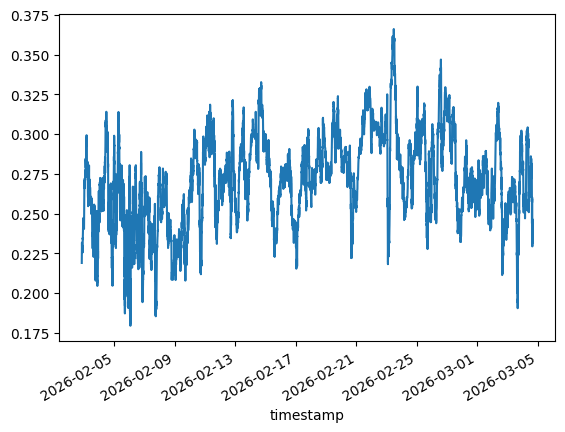

In [159]:
# 原始 fw 的标准差序列 => 假设同分布，fw 后，mean 的 std should be 1.0 / np.sqrt(fw)
factor_series = bars['vwap_dist_sum_imbalance']
factor_series.rolling(100).std().plot()

<Axes: xlabel='timestamp'>

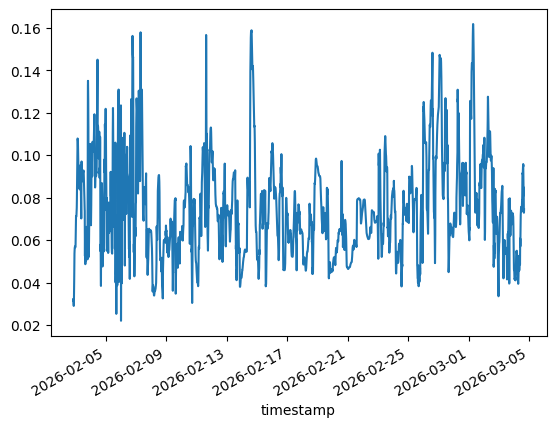

In [ ]:
# 研究 factor 时间序列标准差 => 了解波动 (delta) 的范围
# 以 fw=8, ema=20 为例
# 100个样本点 => 50000 merged trades
factor_ema_series = bars[f'vwap_dist_sum_imbalance_v01_fw8_ema20']
factor_ema_series.rolling(100).std().plot()


<Axes: xlabel='timestamp'>

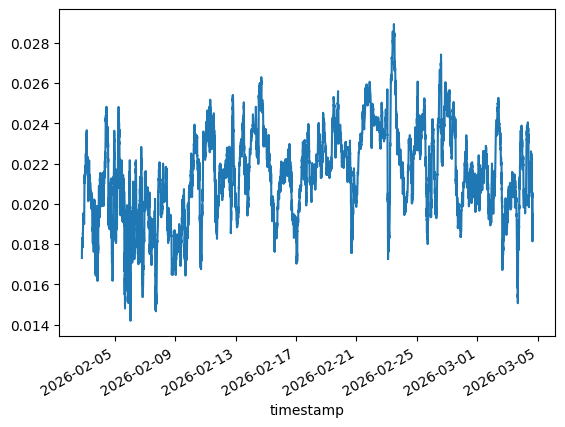

In [163]:
fw = 8
ema_w = 20
# ema 对标准差的影响
lambda_ = 2 / (ema_w + 1)  # = 2/21 ≈ 0.09524
reduction_factor = np.sqrt(lambda_ / (2 - lambda_))
scale_factor = 1.0 / np.sqrt(fw) * reduction_factor
threshold = factor_series.rolling(100).std() * scale_factor
threshold.plot()


<Axes: xlabel='timestamp'>

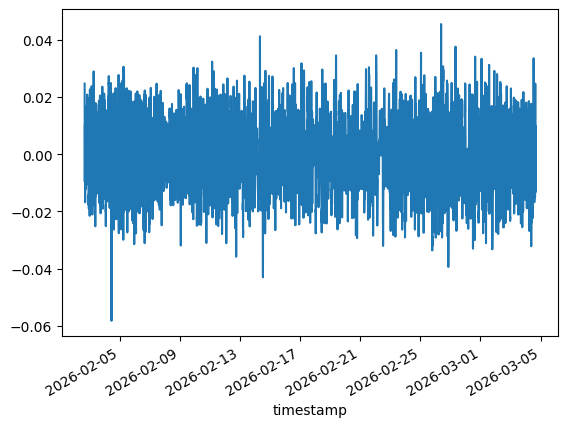

In [155]:
delta_series = factor_series.diff()
delta_series.plot()

<Axes: xlabel='timestamp'>

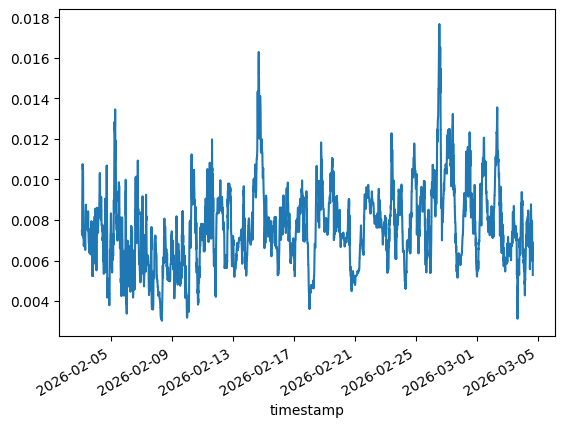

In [164]:
# 100个样本点 => 50000 merged trades
factor_ema_series = bars[f'vwap_dist_sum_imbalance_v01_fw8_ema20']
delta_series = factor_ema_series.diff()

window = 100
rolling_median = delta_series.rolling(window).median()
# 绝对偏差
abs_dev = (delta_series - rolling_median).abs()
# 滚动MAD
rolling_mad = abs_dev.rolling(window).median()
rolling_mad.plot()

In [58]:
def calculate_delta_threshold(delta_series, window=100, method='mad', k=1):
    """
    计算delta的自适应阈值
    
    Parameters:
    -----------
    delta_series : pd.Series
        delta值序列
    window : int
        滚动窗口
    method : str
        'mad' - 基于绝对中位差（推荐，稳健）
        'std' - 基于标准差
        'quantile' - 基于分位数
    k : float
        阈值倍数
    """
    if method == 'mad':
        # 滚动中位数
        rolling_median = delta_series.rolling(window).median()
        # 绝对偏差
        abs_dev = (delta_series - rolling_median).abs()
        # 滚动MAD
        rolling_mad = abs_dev.rolling(window).median()
        threshold = rolling_mad * k
        
    elif method == 'std':
        rolling_std = delta_series.rolling(window).std()
        threshold = rolling_std * k
        
    elif method == 'quantile':
        threshold = delta_series.rolling(window).quantile(0.75)
    
    return threshold.fillna(method='bfill').fillna(method='ffill')

# 修改你的原始函数，集成新功能
def vwap_dist_sum_v02_strategy_enhanced(bars, fw, ema_w, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    """
    增强版策略函数，包含全面绩效指标记录
    """
    factor_name = 'vwap_dist_sum_imbalance_v02'
    
    # 原有的因子计算代码保持不变
    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bars[f'{factor_name}_fw{fw}'].ewm(span=ema_w, min_periods=1).mean()

    bars[f'sign_{factor_name}'] = np.sign(bars[f'{factor_name}_fw{fw}_ema{ema_w}'])

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_ema{ema_w}'].diff()
    bars['delta_threshold'] = calculate_delta_threshold(
        bars['delta'], 
        window=100, 
        method='mad',  # 推荐使用MAD，对异常值稳健
        k=1           #1倍MAD
    )

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

    filter_delta = bars['delta'].abs() > bars['delta_threshold']
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg'] & filter_delta
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] & filter_delta

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw, ema_w
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, ema_w)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw, ema_w, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [217]:
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30]

for fw in fws:
    for ema_w in ema_ws:
        strat_ret = vwap_dist_sum_v02_strategy_enhanced(bars, fw, ema_w)

策略绩效报告 - vwap_dist_sum_imbalance_v02 (fw=3, ema=5)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -48.79%
  多头收益 (原始): -8.53%
  空头收益 (原始): 0.27%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 1003
  多头交易: 501
  空头交易: 502
  反向交易: 1002
  平均持仓Bar数: 15.10
------------------------------------------------------------
【胜率统计】
  总胜率: 44.67%
  多头胜率: 44.51%
  空头胜率: 44.82%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 0.986
  平均盈利: 0.6886%
  平均亏损: -0.5640%
  单笔期望收益: -0.0045%
  最佳交易: 3.7809%
  最差交易: -6.0961%
------------------------------------------------------------
【风险指标】
  夏普比率: -2.155
  最大回撤: -48.97%
  最大回撤持续期 (bars): 11
  卡尔玛比率: -0.996
  年化波动率: 171.44%
------------------------------------------------------------
【费用统计】
  总手续费: 0.581450
  平均每笔手续费: 0.000580
  费率设置: 0.000290
策略绩效报告

fw=8/10 基本上在不同参数条件下都比较稳定，采取 fw = 8/10 (700s)


交易少的时段阈值不对，交易少的时段的阈值收到了前一段时间的影响导致在交易平缓时段阈值出错，长时间持有错误仓位；因此计算阈值的 lookback window 很难设置；还是得动态调整

In [48]:
# import numpy as np
# import pandas as pd
# from pykalman import KalmanFilter

# def kalman_smooth_factor(factor_series, Q=None, R=None, initial_value=None):
#     """
#     使用卡尔曼滤波平滑因子序列（增加数据预处理）
#     """
#     # 1. 删除或填充 NaN/Inf
#     series_clean = factor_series.replace([np.inf, -np.inf], np.nan)
    
#     # 如果全是 NaN，直接返回原序列（或抛出警告）
#     if series_clean.isnull().all():
#         print("警告：因子序列全为无效值，返回原序列")
#         return factor_series, factor_series, pd.Series(np.nan, index=factor_series.index)
    
#     # 向前填充 NaN（根据数据特性选择合适的方法）
#     series_clean = series_clean.fillna(method='ffill').fillna(method='bfill')
    
#     # 2. 可选：对极端值进行截断（防止数值爆炸）
#     # 使用 99% 分位数截断，避免个别极大值影响滤波
#     upper = series_clean.quantile(0.99)
#     lower = series_clean.quantile(0.01)
#     series_clean = series_clean.clip(lower, upper)
    
#     # 3. 转换为 numpy 数组并确保维度正确
#     obs = series_clean.values.reshape(-1, 1).astype(float)
    
#     # 4. 估计噪声参数（如果未提供）
#     if Q is None:
#         Q = np.var(obs[~np.isnan(obs)]) * 0.01  # 使用有效值计算方差
#     if R is None:
#         R = np.var(obs[~np.isnan(obs)]) * 0.05
    
#     # 5. 初始化卡尔曼滤波
#     kf = KalmanFilter(
#         transition_matrices=[1],
#         observation_matrices=[1],
#         initial_state_mean=initial_value or obs[0, 0],
#         initial_state_covariance=Q,
#         transition_covariance=Q,
#         observation_covariance=R
#     )
    
#     # 6. 执行滤波和平滑
#     state_means, state_covs = kf.filter(obs)
#     smoothed_means, smoothed_covs = kf.smooth(obs)
    
#     # 7. 转换回 Series
#     filtered = pd.Series(state_means.flatten(), index=series_clean.index)
#     smoothed = pd.Series(smoothed_means.flatten(), index=series_clean.index)
#     cov = pd.Series(state_covs.flatten(), index=series_clean.index)
    
#     return smoothed, filtered, cov

import numpy as np
import pandas as pd
from pykalman import KalmanFilter

def kalman_filter_factor(factor_series, Q=None, R=None, initial_value=None):
    """
    使用卡尔曼滤波（前向版本，无lookahead bias）
    返回：filtered（实时滤波结果），cov（协方差）
    """
    # 1. 数据预处理
    series_clean = factor_series.replace([np.inf, -np.inf], np.nan)
    
    if series_clean.isnull().all():
        print("警告：因子序列全为无效值，返回原序列")
        return factor_series, pd.Series(np.nan, index=factor_series.index)
    
    # 只使用前向填充，避免未来数据
    series_clean = series_clean.fillna(method='ffill')
    
    # 如果开头有NaN，用第一个有效值填充
    first_valid = series_clean.first_valid_index()
    if first_valid is not None:
        series_clean.iloc[:series_clean.index.get_loc(first_valid)] = series_clean.loc[first_valid]
    
    # 2. 极端值处理 - 使用expanding窗口而不是rolling，避免未来信息
    # 计算到每个时间点的历史分位数
    def get_historical_bounds(s, window=None):
        """获取到当前时间点的历史分位数"""
        if window is None:
            # 使用所有历史数据
            upper = s.expanding().quantile(0.99)
            lower = s.expanding().quantile(0.01)
        else:
            # 使用滚动窗口
            upper = s.rolling(window=window, min_periods=10).quantile(0.99)
            lower = s.rolling(window=window, min_periods=10).quantile(0.01)
        
        # 填充NaN
        upper = upper.fillna(method='bfill').fillna(method='ffill')
        lower = lower.fillna(method='bfill').fillna(method='ffill')
        
        return upper, lower
    
    # 使用expanding窗口（无未来信息）
    upper_bound, lower_bound = get_historical_bounds(series_clean, window=None)
    
    # 应用截断
    series_clean = series_clean.clip(lower_bound, upper_bound)
    
    # 3. 转换为numpy数组
    obs = series_clean.values.reshape(-1, 1).astype(float)
    
    # 4. 估计噪声参数（使用历史数据滚动估计或全局估计）
    valid_obs = obs[~np.isnan(obs)]
    if len(valid_obs) > 10:
        # 使用滚动方差估计，避免未来信息
        rolling_var = pd.Series(valid_obs.flatten()).rolling(window=min(100, len(valid_obs)//2), min_periods=10).var()
        obs_var = rolling_var.iloc[-1] if not rolling_var.isna().all() else np.var(valid_obs)
        
        if Q is None:
            Q = obs_var * 0.05  # 过程噪声
        if R is None:
            R = obs_var * 0.01  # 观测噪声
    else:
        obs_var = 1.0
        Q = 1e-4 if Q is None else Q
        R = 1e-3 if R is None else R
    
    # 5. 处理初始值
    if initial_value is None:
        # 找到第一个有效值
        first_valid_idx = np.where(~np.isnan(obs.flatten()))[0]
        if len(first_valid_idx) > 0:
            initial_state_mean = obs[first_valid_idx[0], 0]
        else:
            initial_state_mean = 0
    else:
        initial_state_mean = initial_value
    
    # 6. 初始化卡尔曼滤波
    kf = KalmanFilter(
        transition_matrices=np.array([[1.0]]),           # 状态转移矩阵 F = 1
        observation_matrices=np.array([[1.0]]),          # 观测矩阵 H = 1
        initial_state_mean=np.array([initial_state_mean]),
        initial_state_covariance=np.array([[Q]]),        # 初始不确定性
        transition_covariance=np.array([[Q]]),           # 过程噪声 Q
        observation_covariance=np.array([[R]]),          # 观测噪声 R
        em_vars=[]  # 不进行EM估计，防止使用未来信息
    )
    
    # 7. 处理NaN值：pykalman不能处理NaN，需要分段处理
    # 找出连续的有效数据段
    valid_mask = ~np.isnan(obs.flatten())
    
    if not valid_mask.any():
        return pd.Series(np.nan, index=series_clean.index), pd.Series(np.nan, index=series_clean.index)
    
    # 初始化结果数组
    n = len(obs)
    state_means = np.full((n, 1), np.nan)
    state_covs = np.full((n, 1, 1), np.nan)
    
    # 分段处理连续的有效数据
    i = 0
    while i < n:
        if valid_mask[i]:
            # 找到连续段的开始
            start = i
            while i < n and valid_mask[i]:
                i += 1
            end = i
            
            # 处理这个连续段
            segment_obs = obs[start:end]
            
            # 对于段的第一个点，可能需要重新初始化
            if start == 0:
                # 第一段，使用初始值
                pass
            else:
                # 非第一段，用前一段最后一个有效值重新初始化
                kf = KalmanFilter(
                    transition_matrices=np.array([[1.0]]),
                    observation_matrices=np.array([[1.0]]),
                    initial_state_mean=state_means[start-1],
                    initial_state_covariance=state_covs[start-1],
                    transition_covariance=np.array([[Q]]),
                    observation_covariance=np.array([[R]]),
                    em_vars=[]
                )
            
            # 滤波
            segment_means, segment_covs = kf.filter(segment_obs)
            state_means[start:end] = segment_means
            state_covs[start:end] = segment_covs
        else:
            i += 1
    
    # 8. 转换回Series
    filtered = pd.Series(state_means.flatten(), index=series_clean.index)
    cov = pd.Series(state_covs[:, 0, 0], index=series_clean.index)
    
    return filtered, cov

# 在你的策略中使用
def vwap_dist_sum_v04_strategy_with_kalman(bars, fw, ema_w, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    factor_name = 'vwap_dist_sum_imbalance_v04'
    
    # 原有因子计算
    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    
    # 使用卡尔曼滤波替代EMA
    filtered_factor, cov = kalman_filter_factor(
        bars[f'{factor_name}_fw{fw}'],
        Q=None,  # 自动估计
        R=None   # 自动估计
    )
    
    # 使用平滑后的因子
    bars[f'{factor_name}_fw{fw}_kalman'] = filtered_factor

    bars[f'sign_{factor_name}'] = np.sign(bars[f'{factor_name}_fw{fw}_kalman'])

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_kalman'].diff()
    # bars['delta_threshold'] = calculate_delta_threshold(
    #     bars['delta'], 
    #     window=100, 
    #     method='mad',  # 推荐使用MAD，对异常值稳健
    #     k=1           #1倍MAD
    # )

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

    # filter_delta = bars['delta'].abs() > bars['delta_threshold']
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg']
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] 

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw, ema_w
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, ema_w)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw, ema_w, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [49]:
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30]

for fw in fws:
    for ema_w in ema_ws:
        strat_ret = vwap_dist_sum_v04_strategy_with_kalman(bars, fw, ema_w)



策略绩效报告 - vwap_dist_sum_imbalance_v04 (fw=3, ema=5)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -98.23%
  多头收益 (原始): 4.08%
  空头收益 (原始): -25.24%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 6510
  多头交易: 3255
  空头交易: 3255
  反向交易: 6509
  平均持仓Bar数: 2.33
------------------------------------------------------------
【胜率统计】
  总胜率: 45.04%
  多头胜率: 45.59%
  空头胜率: 44.49%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 0.975
  平均盈利: 0.2834%
  平均亏损: -0.2387%
  单笔期望收益: -0.0032%
  最佳交易: 3.1874%
  最差交易: -3.2073%
------------------------------------------------------------
【风险指标】
  夏普比率: -13.182
  最大回撤: -98.24%
  最大回撤持续期 (bars): 3
  卡尔玛比率: -1.000
  年化波动率: 178.04%
------------------------------------------------------------
【费用统计】
  总手续费: 3.775510
  平均每笔手续费: 0.000580
  费率设置: 0.000290
策略绩效

In [19]:
def kalman_filter_factor_simple(factor_series, Q=None, R=None, initial_value=None):
    """
    简单的卡尔曼滤波实现（无lookahead bias）
    """
    # 数据预处理
    series_clean = factor_series.replace([np.inf, -np.inf], np.nan).fillna(method='ffill')
    
    if series_clean.isnull().all():
        return factor_series, pd.Series(np.nan, index=factor_series.index)
    
    # 填充开头
    series_clean = series_clean.fillna(series_clean.dropna().iloc[0] if not series_clean.dropna().empty else 0)
    
    # 转换为数组
    obs = series_clean.values
    
    # 估计噪声参数
    obs_var = np.var(obs[~np.isnan(obs)])
    Q = obs_var * 0.01 if Q is None else Q
    R = obs_var * 0.05 if R is None else R
    
    # 手动实现卡尔曼滤波（避免pykalman的限制）
    n = len(obs)
    x_filtered = np.zeros(n)  # 滤波后的状态
    P_filtered = np.zeros(n)  # 协方差
    
    # 初始化
    x_filtered[0] = initial_value if initial_value is not None else obs[0]
    P_filtered[0] = Q
    
    # 前向滤波
    for t in range(1, n):
        if np.isnan(obs[t]):
            # 如果是NaN，保持上一时刻的状态
            x_filtered[t] = x_filtered[t-1]
            P_filtered[t] = P_filtered[t-1] + Q
        else:
            # 预测
            x_pred = x_filtered[t-1]
            P_pred = P_filtered[t-1] + Q
            
            # 更新
            K = P_pred / (P_pred + R)  # 卡尔曼增益
            x_filtered[t] = x_pred + K * (obs[t] - x_pred)
            P_filtered[t] = (1 - K) * P_pred
    
    # 转换回Series
    filtered = pd.Series(x_filtered, index=series_clean.index)
    cov = pd.Series(P_filtered, index=series_clean.index)
    
    return filtered, cov

def vwap_dist_sum_v03_strategy_with_kalman(bars, fw, ema_w, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    factor_name = 'vwap_dist_sum_imbalance_v03'
    
    # 原有因子计算
    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    
    # 使用卡尔曼滤波替代EMA
    filtered_factor, cov = kalman_filter_factor_simple(
        bars[f'{factor_name}_fw{fw}'],
        Q=None,  # 自动估计
        R=None   # 自动估计
    )
    
    # 使用平滑后的因子
    bars[f'{factor_name}_fw{fw}_kalman'] = filtered_factor

    bars[f'sign_{factor_name}'] = np.sign(bars[f'{factor_name}_fw{fw}_kalman'])

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_kalman'].diff()
    # bars['delta_threshold'] = calculate_delta_threshold(
    #     bars['delta'], 
    #     window=100, 
    #     method='mad',  # 推荐使用MAD，对异常值稳健
    #     k=1           #1倍MAD
    # )

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

    # filter_delta = bars['delta'].abs() > bars['delta_threshold']
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg']
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] 

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw, ema_w
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, ema_w)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw, ema_w, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [20]:
fws = [3, 5, 8, 10]
kws = [5, 10, 20, 30, 50, 100, 200]

for fw in fws:
    for kw in kws:
        strat_ret = vwap_dist_sum_v03_strategy_with_kalman(bars, fw, kw)

策略绩效报告 - vwap_dist_sum_imbalance_v03 (fw=3, ema=5)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -94.15%
  多头收益 (原始): -16.49%
  空头收益 (原始): 11.26%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 4762
  多头交易: 2381
  空头交易: 2381
  反向交易: 4761
  平均持仓Bar数: 3.18
------------------------------------------------------------
【胜率统计】
  总胜率: 45.61%
  多头胜率: 44.81%
  空头胜率: 46.41%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 0.995
  平均盈利: 0.3284%
  平均亏损: -0.2773%
  单笔期望收益: -0.0007%
  最佳交易: 2.7913%
  最差交易: -3.2073%
------------------------------------------------------------
【风险指标】
  夏普比率: -9.307
  最大回撤: -94.25%
  最大回撤持续期 (bars): 4
  卡尔玛比率: -0.999
  年化波动率: 176.80%
------------------------------------------------------------
【费用统计】
  总手续费: 2.761670
  平均每笔手续费: 0.000580
  费率设置: 0.000290
策略绩效

In [226]:
def kalman_filter_factor(factor_series, Q=None, R=None, initial_value=None, window=100):
    """
    使用卡尔曼滤波（因果滤波）平滑因子，并滚动估计 Q/R（可选）
    """
    # 数据清洗（同前）
    series_clean = factor_series.replace([np.inf, -np.inf], np.nan)
    series_clean = series_clean.fillna(method='ffill').fillna(method='bfill')
    
    # 如果 Q 和 R 未指定，则使用滚动窗口估计（避免未来信息）
    if Q is None or R is None:
        # 使用前 window 个有效值估计初始 Q/R
        valid_data = series_clean.dropna().values
        if len(valid_data) < window:
            window = len(valid_data)
        init_data = valid_data[:window]
        init_var = np.var(init_data)
        Q = init_var * 0.01 if Q is None else Q
        R = init_var * 0.05 if R is None else R
    
    # 转换为 numpy
    obs = series_clean.values.reshape(-1, 1).astype(float)
    
    # 初始化卡尔曼滤波
    kf = KalmanFilter(
        transition_matrices=[1],
        observation_matrices=[1],
        initial_state_mean=initial_value or obs[0, 0],
        initial_state_covariance=Q,
        transition_covariance=Q,
        observation_covariance=R
    )
    
    # 只运行滤波（因果）
    state_means, state_covs = kf.filter(obs)
    
    filtered = pd.Series(state_means.flatten(), index=series_clean.index)
    cov = pd.Series(state_covs.flatten(), index=series_clean.index)
    
    return filtered, cov

# 在你的策略中使用
def vwap_dist_sum_v03_strategy_with_kalman(bars, fw, kw, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    factor_name = 'vwap_dist_sum_imbalance_v03'

    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    
    # 使用卡尔曼滤波替代EMA
    filtered_factor, cov = kalman_filter_factor(bars[f'{factor_name}_fw{fw}'], Q=None, R=None, window=kw)
    bars[f'{factor_name}_fw{fw}_kw{kw}'] = filtered_factor

    # 画 indicators 图
    # draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw)

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_kw{kw}'].diff()
    # bars['delta_threshold'] = calculate_delta_threshold(
    #     bars['delta'], 
    #     window=100, 
    #     method='mad',  # 推荐使用MAD，对异常值稳健
    #     k=1           #1倍MAD
    # )

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

    # filter_delta = bars['delta'].abs() > bars['delta_threshold']
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg']
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] 

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw, kw
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, kw)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw, kw, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [227]:
fws = [3, 5, 8, 10]
kws = [5, 10, 20, 30, 50, 100, 200]

for fw in fws:
    for kw in kws:
        strat_ret = vwap_dist_sum_v03_strategy_with_kalman(bars, fw, kw)



策略绩效报告 - vwap_dist_sum_imbalance_v03 (fw=3, ema=5)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -94.15%
  多头收益 (原始): -16.49%
  空头收益 (原始): 11.26%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 4762
  多头交易: 2381
  空头交易: 2381
  反向交易: 4761
  平均持仓Bar数: 3.18
------------------------------------------------------------
【胜率统计】
  总胜率: 45.61%
  多头胜率: 44.81%
  空头胜率: 46.41%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 0.995
  平均盈利: 0.3284%
  平均亏损: -0.2773%
  单笔期望收益: -0.0007%
  最佳交易: 2.7913%
  最差交易: -3.2073%
------------------------------------------------------------
【风险指标】
  夏普比率: -9.307
  最大回撤: -94.25%
  最大回撤持续期 (bars): 4
  卡尔玛比率: -0.999
  年化波动率: 176.80%
------------------------------------------------------------
【费用统计】
  总手续费: 2.761670
  平均每笔手续费: 0.000580
  费率设置: 0.000290
策略绩效

KeyError: 'vwap_dist_sum_imbalance_v03_fw5_kalman'

In [24]:

filtered_factor, cov = kalman_filter_factor(bars[f'vwap_dist_sum_imbalance_v03_fw3'], Q=None, R=None, window=kw)
filtered_factor

NameError: name 'kalman_filter_factor' is not defined

In [194]:
bars['vwap_dist_sum_imbalance'] = (bars[f'buy_vwap_dist_sum'] - bars[f'sell_vwap_dist_sum']) / (bars[f'buy_vwap_dist_sum'] + bars[f'sell_vwap_dist_sum'] + 1e-10)

<Axes: xlabel='timestamp'>

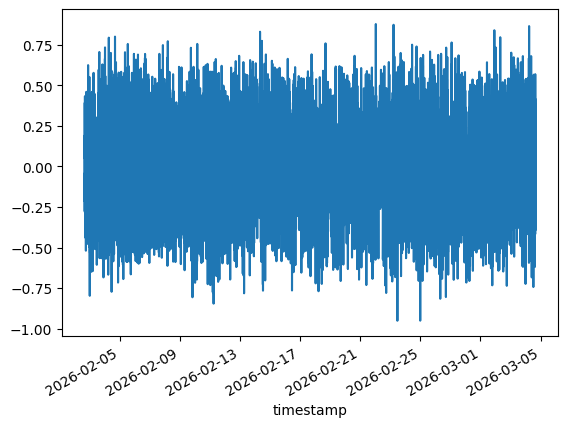

In [195]:
bars[f'vwap_dist_sum_imbalance'].plot()

<Axes: xlabel='timestamp'>

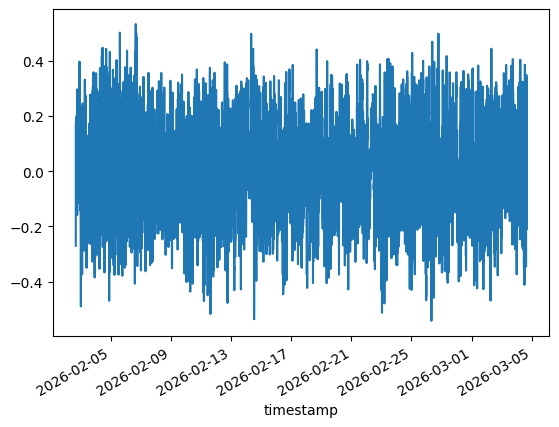

In [ ]:
filtered_factor, cov = kalman_filter_factor(bars[f'vwap_dist_sum_imbalance'], Q=None, R=None, window=100)
filtered_factor.plot()

<Axes: xlabel='timestamp'>

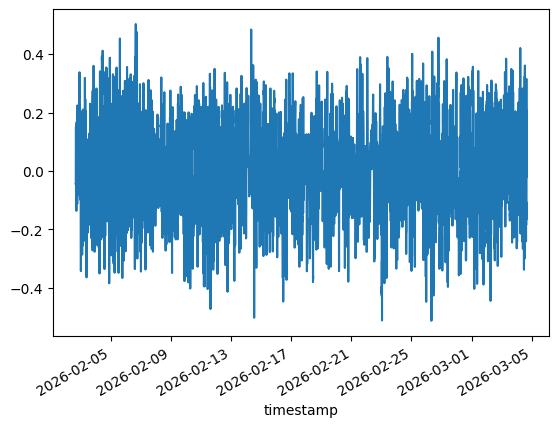

In [26]:
filtered_factor, cov = kalman_filter_factor_simple(bars[f'vwap_dist_sum_imbalance_v03_fw3'], Q=None, R=None)
filtered_factor.plot()

<Axes: xlabel='timestamp'>

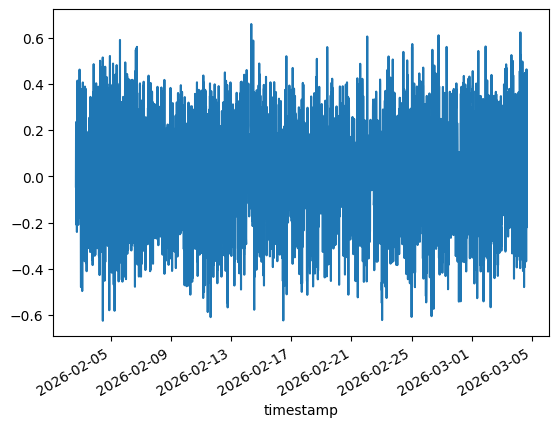

In [196]:
bars[f'vwap_dist_sum_imbalance_fw3'].plot()

<Axes: xlabel='timestamp'>

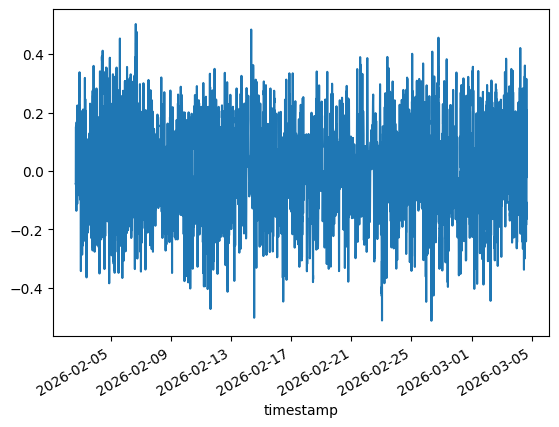

In [197]:
filtered_factor.plot()

In [29]:
def kaufman_ama(series, n=10, fast=2, slow=30):
    """
    Kaufman Adaptive Moving Average
    series: pd.Series
    n: 计算效率比率的窗口
    fast: 快速EMA的平滑常数 (通常=2)
    slow: 慢速EMA的平滑常数 (通常=30)
    """
    # 计算方向动量
    change = series.diff(n).abs()
    # 计算每日波动总和
    volatility = series.diff().abs().rolling(n).sum()
    # 效率比率 ER = change / volatility
    er = change / volatility
    er = er.fillna(0)
    
    # 计算平滑常数
    fast_sc = 2 / (fast + 1)
    slow_sc = 2 / (slow + 1)
    sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2  # 平方加快响应
    
    ama = series.copy()
    for i in range(1, len(series)):
        ama.iloc[i] = ama.iloc[i-1] + sc.iloc[i] * (series.iloc[i] - ama.iloc[i-1])
    return ama

In [37]:
def vwap_dist_sum_v05_strategy_with_kalman(bars, fw, kw, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    factor_name = 'vwap_dist_sum_imbalance_v05'

    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    
    # 使用卡尔曼滤波替代EMA
    filtered_factor = kaufman_ama(bars[f'{factor_name}_fw{fw}'])
    bars[f'{factor_name}_fw{fw}_kw{kw}'] = filtered_factor

    # 画 indicators 图
    # draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw)

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_kw{kw}'].diff()
    # bars['delta_threshold'] = calculate_delta_threshold(
    #     bars['delta'], 
    #     window=100, 
    #     method='mad',  # 推荐使用MAD，对异常值稳健
    #     k=1           #1倍MAD
    # )

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

    # filter_delta = bars['delta'].abs() > bars['delta_threshold']
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg']
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] 

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # # 画 indicators 图
    # draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw, kw
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, kw)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw, kw, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [39]:
def bilateral_filter(series, window=10, sigma_d=5.0, sigma_r=0.1):
    """
    sigma_d: 时间距离的衰减参数（越大考虑越远）
    sigma_r: 数值差异的衰减参数（越大允许更多差异）
    """
    result = series.copy()
    for i in range(len(series)):
        if i < window or i >= len(series)-window:
            result.iloc[i] = series.iloc[i]
            continue
        # 选取窗口
        start = max(0, i - window)
        end = min(len(series), i + window + 1)
        window_data = series.iloc[start:end]
        # 计算时间权重和数值权重
        time_dist = np.abs(np.arange(len(window_data)) - (i - start))
        value_diff = np.abs(window_data - series.iloc[i])
        weight = np.exp(-0.5 * (time_dist / sigma_d)**2) * np.exp(-0.5 * (value_diff / sigma_r)**2)
        weight /= weight.sum()
        result.iloc[i] = np.sum(weight * window_data)
    return result

In [46]:
def vwap_dist_sum_v06_strategy(bars, fw, ema_w, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    factor_name = 'vwap_dist_sum_imbalance_v06'

    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    
    bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = bilateral_filter(bars[f'{factor_name}_fw{fw}'], ema_w)

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, ema_w)

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_ema{ema_w}'].diff()
    # bars['delta_threshold'] = calculate_delta_threshold(
    #     bars['delta'], 
    #     window=100, 
    #     method='mad',  # 推荐使用MAD，对异常值稳健
    #     k=1           #1倍MAD
    # )

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

    # filter_delta = bars['delta'].abs() > bars['delta_threshold']
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg']
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] 

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # # 画 indicators 图
    # draw_price_factor_graph_w_indicators(bars.copy(), factor_name, ema_w)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw, kw
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, kw)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw, kw, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [47]:
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30, 50, 100, 200]

for fw in fws:
    for ema_w in ema_ws:
        strat_ret = vwap_dist_sum_v06_strategy(bars, fw, ema_w)


KeyError: 'long_entry_vwap_dist_sum_imbalance_v06'

多头 空头参数不一致

In [55]:
def calculate_delta_threshold(delta_series, window=100, method='mad', k=1):
    """
    计算delta的自适应阈值
    
    Parameters:
    -----------
    delta_series : pd.Series
        delta值序列
    window : int
        滚动窗口
    method : str
        'mad' - 基于绝对中位差（推荐，稳健）
        'std' - 基于标准差
        'quantile' - 基于分位数
    k : float
        阈值倍数
    """
    if method == 'mad':
        # 滚动中位数
        rolling_median = delta_series.rolling(window).median()
        # 绝对偏差
        abs_dev = (delta_series - rolling_median).abs()
        # 滚动MAD
        rolling_mad = abs_dev.rolling(window).median()
        threshold = rolling_mad * k
        
    elif method == 'std':
        rolling_std = delta_series.rolling(window).std()
        threshold = rolling_std * k
        
    elif method == 'quantile':
        threshold = delta_series.rolling(window).quantile(0.75)
    
    return threshold.fillna(method='bfill').fillna(method='ffill')

# 修改你的原始函数，集成新功能
def vwap_dist_sum_v40_strategy_enhanced(bars, fw1, ema_w1, fw2, ema_w2, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    """
    增强版策略函数，包含全面绩效指标记录
    """
    factor_name = 'vwap_dist_sum_imbalance_v02'
    
    # 原有的因子计算代码保持不变
    bars[f'buy_vwap_dist_sum_fw{fw1}'] = bars['buy_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'sell_vwap_dist_sum_fw{fw1}'] = bars['sell_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'{factor_name}_fw{fw1}'] = (bars[f'buy_vwap_dist_sum_fw{fw1}'] - bars[f'sell_vwap_dist_sum_fw{fw1}']) / (bars[f'buy_vwap_dist_sum_fw{fw1}'] + bars[f'sell_vwap_dist_sum_fw{fw1}'] + 1e-10)
    bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'] = bars[f'{factor_name}_fw{fw1}'].ewm(span=ema_w1, min_periods=1).mean()

    bars[f'buy_vwap_dist_sum_fw{fw2}'] = bars['buy_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'sell_vwap_dist_sum_fw{fw2}'] = bars['sell_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'{factor_name}_fw{fw2}'] = (bars[f'buy_vwap_dist_sum_fw{fw2}'] - bars[f'sell_vwap_dist_sum_fw{fw2}']) / (bars[f'buy_vwap_dist_sum_fw{fw2}'] + bars[f'sell_vwap_dist_sum_fw{fw2}'] + 1e-10)
    bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'] = bars[f'{factor_name}_fw{fw2}'].ewm(span=ema_w2, min_periods=1).mean()

    bars[f'delta1'] = bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'].diff()
    bars[f'delta2'] = bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'].diff()
    bars['delta_threshold1'] = calculate_delta_threshold(
        bars['delta1'], 
        window=100, 
        method='mad',  # 推荐使用MAD，对异常值稳健
        k=1           #1倍MAD
    )
    bars['delta_threshold2'] = calculate_delta_threshold(
        bars['delta2'], 
        window=100, 
        method='mad',  # 推荐使用MAD，对异常值稳健
        k=1           #1倍MAD
    )

    bars['delta_sign_raw1'] = np.sign(bars['delta1'])
    bars['delta_sign1'] = bars['delta_sign_raw1'].replace(0, method='ffill')
    bars['delta_sign_raw2'] = np.sign(bars['delta2'])
    bars['delta_sign2'] = bars['delta_sign_raw2'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign2'].shift(1) == 1) & (bars['delta_sign2'] == -1)
    bars['reversal_pos'] = (bars['delta_sign1'].shift(1) == -1) & (bars['delta_sign1'] == 1)

    filter_delta1 = bars['delta1'].abs() > bars['delta_threshold1']
    filter_delta2 = bars['delta2'].abs() > bars['delta_threshold2']

    bars[f'short_entry_{factor_name}'] = bars['reversal_neg'] & filter_delta2
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] & filter_delta1

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # # 画 indicators 图
    # draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw1, ema_w1
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw1, ema_w1)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw1, ema_w1, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [56]:
vwap_dist_sum_v40_strategy_enhanced(bars, 8, 10, 10, 10)

策略绩效报告 - vwap_dist_sum_imbalance_v02 (fw=8, ema=10)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): 45.73%
  多头收益 (原始): 26.44%
  空头收益 (原始): 28.46%
  基准收益: -11.60%
  年化收益率: 46771713.74%
------------------------------------------------------------
【交易统计】
  总交易次数: 187
  多头交易: 94
  空头交易: 93
  反向交易: 186
  平均持仓Bar数: 80.55
------------------------------------------------------------
【胜率统计】
  总胜率: 49.73%
  多头胜率: 47.87%
  空头胜率: 51.61%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 1.459
  平均盈利: 1.7970%
  平均亏损: -1.2182%
  单笔期望收益: 0.2813%
  最佳交易: 12.5763%
  最差交易: -4.4340%
------------------------------------------------------------
【风险指标】
  夏普比率: 1.453
  最大回撤: -24.96%
  最大回撤持续期 (bars): 98
  卡尔玛比率: 1.832
  年化波动率: 169.13%
------------------------------------------------------------
【费用统计】
  总手续费: 0.108170
  平均每笔手续费: 0.000578
  费率设置: 0.000290


(                               open        high     low       close    volume  \
 timestamp                                                                       
 2026-02-02 16:00:01.690  104.582359  104.590000  104.38  104.470000   5398.11   
 2026-02-02 16:01:21.081  104.479890  104.610000  104.40  104.570000   6154.29   
 2026-02-02 16:02:56.502  104.574022  104.590000  104.35  104.410000   9101.02   
 2026-02-02 16:04:36.466  104.420000  104.460000  104.17  104.460000   9769.26   
 2026-02-02 16:05:56.828  104.470000  104.740000  104.43  104.740000   5534.80   
 ...                             ...         ...     ...         ...       ...   
 2026-03-04 15:54:13.391   92.540000   92.560000   92.40   92.470000   6272.20   
 2026-03-04 15:55:42.573   92.479479   92.610000   92.32   92.590000   6497.63   
 2026-03-04 15:57:39.695   92.582723   92.982745   92.55   92.799964  15382.10   
 2026-03-04 15:58:09.265   92.800000   93.080000   92.80   92.980000  18363.20   
 2026-03-04 15:5

In [84]:
def calculate_delta_threshold(delta_series, window=100, method='mad', k=1):
    """
    计算delta的自适应阈值
    
    Parameters:
    -----------
    delta_series : pd.Series
        delta值序列
    window : int
        滚动窗口
    method : str
        'mad' - 基于绝对中位差（推荐，稳健）
        'std' - 基于标准差
        'quantile' - 基于分位数
    k : float
        阈值倍数
    """
    if method == 'mad':
        # 滚动中位数
        rolling_median = delta_series.rolling(window).median()
        # 绝对偏差
        abs_dev = (delta_series - rolling_median).abs()
        # 滚动MAD
        rolling_mad = abs_dev.rolling(window).median()
        threshold = rolling_mad * k
        
    elif method == 'std':
        rolling_std = delta_series.rolling(window).std()
        threshold = rolling_std * k
        
    elif method == 'quantile':
        threshold = delta_series.rolling(window).quantile(0.75)
    
    return threshold.fillna(method='bfill').fillna(method='ffill')

# 修改你的原始函数，集成新功能
def vwap_dist_sum_v40_strategy_enhanced(bars, fw1, ema_w1, fw2, ema_w2, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    """
    增强版策略函数，包含全面绩效指标记录
    """
    factor_name = 'vwap_dist_sum_imbalance_v40'
    
    # 原有的因子计算代码保持不变
    bars[f'buy_vwap_dist_sum_fw{fw1}'] = bars['buy_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'sell_vwap_dist_sum_fw{fw1}'] = bars['sell_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'{factor_name}_fw{fw1}'] = (bars[f'buy_vwap_dist_sum_fw{fw1}'] - bars[f'sell_vwap_dist_sum_fw{fw1}']) / (bars[f'buy_vwap_dist_sum_fw{fw1}'] + bars[f'sell_vwap_dist_sum_fw{fw1}'] + 1e-10)
    bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'] = bars[f'{factor_name}_fw{fw1}'].ewm(span=ema_w1, min_periods=1).mean()

    bars[f'buy_vwap_dist_sum_fw{fw2}'] = bars['buy_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'sell_vwap_dist_sum_fw{fw2}'] = bars['sell_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'{factor_name}_fw{fw2}'] = (bars[f'buy_vwap_dist_sum_fw{fw2}'] - bars[f'sell_vwap_dist_sum_fw{fw2}']) / (bars[f'buy_vwap_dist_sum_fw{fw2}'] + bars[f'sell_vwap_dist_sum_fw{fw2}'] + 1e-10)
    bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'] = bars[f'{factor_name}_fw{fw2}'].ewm(span=ema_w2, min_periods=1).mean()

    bars[f'delta1'] = bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'].diff()
    bars[f'delta2'] = bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'].diff()
    bars['delta_threshold1'] = calculate_delta_threshold(
        bars['delta1'], 
        window=100, 
        method='mad',  # 推荐使用MAD，对异常值稳健
        k=1.5      #1倍MAD
    )
    bars['delta_threshold2'] = calculate_delta_threshold(
        bars['delta2'], 
        window=100, 
        method='mad',  # 推荐使用MAD，对异常值稳健
        k=1           #1倍MAD
    )

    bars['delta_sign_raw1'] = np.sign(bars['delta1'])
    bars['delta_sign1'] = bars['delta_sign_raw1'].replace(0, method='ffill')
    bars['delta_sign_raw2'] = np.sign(bars['delta2'])
    bars['delta_sign2'] = bars['delta_sign_raw2'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign2'].shift(1) == 1) & (bars['delta_sign2'] == -1)
    bars['reversal_pos'] = (bars['delta_sign1'].shift(1) == -1) & (bars['delta_sign1'] == 1)

    filter_delta1 = bars['delta1'].abs() > bars['delta_threshold1']
    filter_delta2 = bars['delta2'].abs() > bars['delta_threshold2']

    bars[f'short_entry_{factor_name}'] = bars['reversal_neg'] & filter_delta2
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] & filter_delta1

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # # 画 indicators 图
    # draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw1, ema_w1
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw1, ema_w1)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw1, ema_w1, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [85]:
vwap_dist_sum_v40_strategy_enhanced(bars, 8, 10, 10, 10)

策略绩效报告 - vwap_dist_sum_imbalance_v40 (fw=8, ema=10)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): 52.32%
  多头收益 (原始): 18.58%
  空头收益 (原始): 34.76%
  基准收益: -11.60%
  年化收益率: 216293561.10%
------------------------------------------------------------
【交易统计】
  总交易次数: 83
  多头交易: 41
  空头交易: 42
  反向交易: 82
  平均持仓Bar数: 180.52
------------------------------------------------------------
【胜率统计】
  总胜率: 56.63%
  多头胜率: 58.54%
  空头胜率: 54.76%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 1.778
  平均盈利: 2.4786%
  平均亏损: -1.8203%
  单笔期望收益: 0.6140%
  最佳交易: 17.0782%
  最差交易: -10.5874%
------------------------------------------------------------
【风险指标】
  夏普比率: 1.611
  最大回撤: -28.18%
  最大回撤持续期 (bars): 178
  卡尔玛比率: 1.857
  年化波动率: 168.61%
------------------------------------------------------------
【费用统计】
  总手续费: 0.047850
  平均每笔手续费: 0.000577
  费率设置: 0.000290


(                               open        high     low       close    volume  \
 timestamp                                                                       
 2026-02-02 16:00:01.690  104.582359  104.590000  104.38  104.470000   5398.11   
 2026-02-02 16:01:21.081  104.479890  104.610000  104.40  104.570000   6154.29   
 2026-02-02 16:02:56.502  104.574022  104.590000  104.35  104.410000   9101.02   
 2026-02-02 16:04:36.466  104.420000  104.460000  104.17  104.460000   9769.26   
 2026-02-02 16:05:56.828  104.470000  104.740000  104.43  104.740000   5534.80   
 ...                             ...         ...     ...         ...       ...   
 2026-03-04 15:54:13.391   92.540000   92.560000   92.40   92.470000   6272.20   
 2026-03-04 15:55:42.573   92.479479   92.610000   92.32   92.590000   6497.63   
 2026-03-04 15:57:39.695   92.582723   92.982745   92.55   92.799964  15382.10   
 2026-03-04 15:58:09.265   92.800000   93.080000   92.80   92.980000  18363.20   
 2026-03-04 15:5

下跌更多，上涨大多假信号，由于出现多头信号前会一直保持空头，因此假多头会造成巨大影响（持有相反仓位) => 提升多头阈值

动态 filter, 随 trading volume 变化

In [86]:
def calculate_delta_threshold(delta_series, window=100, method='mad', k=1, vol_adjusted=False, vol_series=None, local_window=10):
    """
    计算delta的自适应阈值
    
    Parameters:
    -----------
    delta_series : pd.Series
        delta值序列
    window : int
        滚动窗口
    method : str
        'mad' - 基于绝对中位差（推荐，稳健）
        'std' - 基于标准差
        'quantile' - 基于分位数
    k : float
        阈值倍数
    """
    if method == 'mad':
        # 滚动中位数
        rolling_median = delta_series.rolling(window).median()
        # 绝对偏差
        abs_dev = (delta_series - rolling_median).abs()
        # 滚动MAD
        rolling_mad = abs_dev.rolling(window).median()
        threshold = rolling_mad * k
        
    elif method == 'std':
        rolling_std = delta_series.rolling(window).std()
        threshold = rolling_std * k
        
    elif method == 'quantile':
        threshold = delta_series.rolling(window).quantile(0.75)

    if vol_adjusted:
        local_vol_series = vol_series.rolling(local_window).mean()
        avg_vol = local_vol_series.rolling(window).mean()
        threshold = threshold * np.sqrt(local_vol_series / avg_vol)

    # TODO: 增加 local std
    
    return threshold.fillna(method='bfill').fillna(method='ffill')

# 修改你的原始函数，集成新功能
def vwap_dist_sum_v41_strategy_enhanced(bars, fw1, ema_w1, fw2, ema_w2, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    """
    增强版策略函数，包含全面绩效指标记录
    """
    factor_name = 'vwap_dist_sum_imbalance_v41'
    
    # 原有的因子计算代码保持不变
    bars[f'buy_vwap_dist_sum_fw{fw1}'] = bars['buy_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'sell_vwap_dist_sum_fw{fw1}'] = bars['sell_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'{factor_name}_fw{fw1}'] = (bars[f'buy_vwap_dist_sum_fw{fw1}'] - bars[f'sell_vwap_dist_sum_fw{fw1}']) / (bars[f'buy_vwap_dist_sum_fw{fw1}'] + bars[f'sell_vwap_dist_sum_fw{fw1}'] + 1e-10)
    bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'] = bars[f'{factor_name}_fw{fw1}'].ewm(span=ema_w1, min_periods=1).mean()

    bars[f'buy_vwap_dist_sum_fw{fw2}'] = bars['buy_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'sell_vwap_dist_sum_fw{fw2}'] = bars['sell_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'{factor_name}_fw{fw2}'] = (bars[f'buy_vwap_dist_sum_fw{fw2}'] - bars[f'sell_vwap_dist_sum_fw{fw2}']) / (bars[f'buy_vwap_dist_sum_fw{fw2}'] + bars[f'sell_vwap_dist_sum_fw{fw2}'] + 1e-10)
    bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'] = bars[f'{factor_name}_fw{fw2}'].ewm(span=ema_w2, min_periods=1).mean()

    bars[f'delta1'] = bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'].diff()
    bars[f'delta2'] = bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'].diff()

    bars['delta_threshold1'] = calculate_delta_threshold(
        bars['delta1'], 
        window=100, 
        method='mad',  # 推荐使用MAD，对异常值稳健
        k=1.5,         #1.5倍MAD
        vol_adjusted=True, vol_series=bars['volume'], local_window=10
    )
    bars['delta_threshold2'] = calculate_delta_threshold(
        bars['delta2'], 
        window=100, 
        method='mad',  # 推荐使用MAD，对异常值稳健
        k=1,          #1倍MAD
        vol_adjusted=True, vol_series=bars['volume'], local_window=10
    )

    bars['delta_sign_raw1'] = np.sign(bars['delta1'])
    bars['delta_sign1'] = bars['delta_sign_raw1'].replace(0, method='ffill')
    bars['delta_sign_raw2'] = np.sign(bars['delta2'])
    bars['delta_sign2'] = bars['delta_sign_raw2'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign2'].shift(1) == 1) & (bars['delta_sign2'] == -1)
    bars['reversal_pos'] = (bars['delta_sign1'].shift(1) == -1) & (bars['delta_sign1'] == 1)

    filter_delta1 = bars['delta1'].abs() > bars['delta_threshold1']
    filter_delta2 = bars['delta2'].abs() > bars['delta_threshold2']

    bars[f'short_entry_{factor_name}'] = bars['reversal_neg'] & filter_delta2
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] & filter_delta1

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # # 画 indicators 图
    # draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw1, ema_w1
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw1, ema_w1)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw1, ema_w1, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [87]:
vwap_dist_sum_v41_strategy_enhanced(bars, 8, 10, 10, 10)

/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_4923/2855026963.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw1}'] = (bars[f'buy_vwap_dist_sum_fw{fw1}'] - bars[f'sell_vwap_dist_sum_fw{fw1}']) / (bars[f'buy_vwap_dist_sum_fw{fw1}'] + bars[f'sell_vwap_dist_sum_fw{fw1}'] + 1e-10)
/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_4923/2855026963.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'] = bars[f'{factor_name}_fw{fw1}'].ewm(span=

策略绩效报告 - vwap_dist_sum_imbalance_v41 (fw=8, ema=10)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): 66.15%
  多头收益 (原始): 26.27%
  空头收益 (原始): 38.77%
  基准收益: -11.60%
  年化收益率: 4398735579.80%
------------------------------------------------------------
【交易统计】
  总交易次数: 92
  多头交易: 46
  空头交易: 46
  反向交易: 91
  平均持仓Bar数: 162.61
------------------------------------------------------------
【胜率统计】
  总胜率: 54.35%
  多头胜率: 56.52%
  空头胜率: 52.17%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 1.954
  平均盈利: 2.4646%
  平均亏损: -1.5014%
  单笔期望收益: 0.6540%
  最佳交易: 9.8929%
  最差交易: -10.5874%
------------------------------------------------------------
【风险指标】
  夏普比率: 1.915
  最大回撤: -27.10%
  最大回撤持续期 (bars): 201
  卡尔玛比率: 2.441
  年化波动率: 168.51%
------------------------------------------------------------
【费用统计】
  总手续费: 0.053070
  平均每笔手续费: 0.000577
  费率设置: 0.000290


(                               open        high     low       close    volume  \
 timestamp                                                                       
 2026-02-02 16:00:01.690  104.582359  104.590000  104.38  104.470000   5398.11   
 2026-02-02 16:01:21.081  104.479890  104.610000  104.40  104.570000   6154.29   
 2026-02-02 16:02:56.502  104.574022  104.590000  104.35  104.410000   9101.02   
 2026-02-02 16:04:36.466  104.420000  104.460000  104.17  104.460000   9769.26   
 2026-02-02 16:05:56.828  104.470000  104.740000  104.43  104.740000   5534.80   
 ...                             ...         ...     ...         ...       ...   
 2026-03-04 15:54:13.391   92.540000   92.560000   92.40   92.470000   6272.20   
 2026-03-04 15:55:42.573   92.479479   92.610000   92.32   92.590000   6497.63   
 2026-03-04 15:57:39.695   92.582723   92.982745   92.55   92.799964  15382.10   
 2026-03-04 15:58:09.265   92.800000   93.080000   92.80   92.980000  18363.20   
 2026-03-04 15:5

before:

策略绩效报告 - vwap_dist_sum_imbalance_v02 (fw=10, ema=10)

回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162

【收益指标】
  策略总收益 (净): 38.24%
  多头收益 (原始): 13.47%
  空头收益 (原始): 33.29%
  基准收益: -11.60%
  年化收益率: 7504721.64%

【交易统计】
  总交易次数: 155
  多头交易: 78
  空头交易: 77
  反向交易: 154
  平均持仓Bar数: 96.74

【胜率统计】
  总胜率: 49.68%
  多头胜率: 47.44%
  空头胜率: 51.95%

【盈亏分析】
  盈亏比 (Profit Factor): 1.422
  平均盈利: 1.9898%
  平均亏损: -1.3815%
  单笔期望收益: 0.2933%
  最佳交易: 6.9205%
  最差交易: -7.8870%

【风险指标】
  夏普比率: 1.270
  最大回撤: -23.02%
  最大回撤持续期 (bars): 167
  卡尔玛比率: 1.661
  年化波动率: 168.91%

【费用统计】
  总手续费: 0.089610
  平均每笔手续费: 0.000578
  费率设置: 0.000290

动态调整 ema 平滑窗口？

buy / sell 分别止损；

filter threshold 动态调整不够及时？  把 filter threshold 画在信号图里，研究滞后性

如何确定仓位？ 根据信号量定？ 感觉离 imbalance=0 越远 以及 离 imbalance = 0 的时间来定，应该仓位越大？因为反转可能性越大？ 但也可能反弹后继续延续趋势（这种情况应该小仓位）？  简单一点的话，直接根据 vol 定；

把 imbalance 和 imbalance delta 两个信号和一起看？

In [59]:
def draw_price_factor_graph(df, factor_name, buy_factor_name, sell_factor_name, buy_filter_name, sell_filter_name):
    df = bars.copy()

    close = df["close"]
    buy_factor = df[buy_factor_name] if buy_factor_name in df.columns else None
    sell_factor = df[sell_factor_name] if sell_factor_name in df.columns else None
    buy_filter = df[buy_filter_name] if buy_filter_name in df.columns else None
    sell_filter = df[sell_filter_name] if sell_filter_name in df.columns else None

    # Use bar index for x-axis (works for both time and trade-count bars)
    x = df.index

    n_rows = 3 
    row_heights = [0.6, 0.2, 0.2]
    subplot_titles = ["Price", "BuyFactor", "SellFactor"]

    fig = make_subplots(
        rows=n_rows, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        row_heights=row_heights,
        subplot_titles=subplot_titles,
    )

    # Row 1: Price line
    fig.add_trace(go.Scatter(
        x=x, y=close.values, mode="lines", name="Price",
        line=dict(color="#1f77b4", width=1.2),
    ), row=1, col=1)


    # Row 2: BuyFactor with SMA / EMA overlays
    if buy_factor is not None:
        fig.add_trace(go.Scatter(
            x=x, y=buy_factor.values, mode="lines", name="BuyFactor",
            line=dict(color="#9b59b6", width=0.8),
        ), row=2, col=1)

    if buy_filter is not None:
        fig.add_trace(go.Scatter(
            x=x, y=buy_filter.values, mode="lines", name="BuyFilter",
            line=dict(color="#9b59b6", width=0.8),
        ), row=2, col=1)

    fig.update_layout(
        title=dict(
            text=(f"{buy_factor_name}"),
            font=dict(size=14),
        ),
        height=800,
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        margin=dict(l=60, r=30, t=80, b=40),
    )

    fig.add_trace(go.Scatter(
        x=x, y=sell_factor.values, mode="lines", name="SellFactor",
        line=dict(color="#9b59b6", width=0.8),
    ), row=3, col=1)    

    if sell_filter is not None:
        fig.add_trace(go.Scatter(
            x=x, y=sell_filter.values, mode="lines", name="SellFilter",
            line=dict(color="#9b59b6", width=0.8),
        ), row=3, col=1)

    fig.update_layout(
            title=dict(
                text=(f"{sell_factor_name}"),
                font=dict(size=14),
            ),
            height=800,
            template="plotly_white",
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
            margin=dict(l=60, r=30, t=80, b=40),
        )

    # Enable x-axis range slider on the bottom subplot for scrolling
    fig.update_xaxes(rangeslider=dict(visible=True, thickness=0.05), row=n_rows, col=1)
    fig.update_xaxes(showticklabels=True, row=1, col=1)

    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    os.makedirs(output_dir / factor_name, exist_ok=True)
    html_path = output_dir / factor_name / "price_position_interactive.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")

    return html_path

In [60]:
draw_price_factor_graph(bars.copy(),
                       'vwap_dist_sum_imbalance_v02',
                       'vwap_dist_sum_imbalance_v02_fw8_ema10',
                       'vwap_dist_sum_imbalance_v02_fw10_ema10',
                       'delta_threshold1',
                       'delta_threshold2')

PosixPath('/Volumes/Lexar/mean_reversion_data/backtest_results/vwap_dist_sum_imbalance_v02/price_position_interactive.html')

In [65]:
def rolling_polyfit_smooth(series, window, polyorder=3):
    """
    滚动多项式拟合平滑（无lookahead）
    只使用过去的数据拟合，预测当前点
    """
    result = series.copy()
    values = series.values
    
    for i in range(len(series)):
        if i < window:
            # 窗口不足时用原值
            result.iloc[i] = values[i]
            continue
        
        # 只使用过去window个点
        start = i - window + 1
        y_window = values[start:i+1]
        x_window = np.arange(len(y_window))
        
        try:
            # 多项式拟合
            coeffs = np.polyfit(x_window, y_window, polyorder)
            # 预测最后一个点（当前点）
            result.iloc[i] = np.polyval(coeffs, len(y_window)-1)
        except:
            result.iloc[i] = values[i]
    
    return result


def vwap_dist_sum_v50_strategy_enhanced(bars, buy_params, sell_params, poly_order=3, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    """
    增强版策略函数，包含全面绩效指标记录
    """
    factor_name = 'vwap_dist_sum_imbalance_v50'

    fw1 = buy_params.get('fw', 8)
    ema_w1 = buy_params.get('ema_w', 10)

    sell_params = buy_params if sell_params is None else sell_params

    fw2 = sell_params.get('fw', 8)
    ema_w2 = sell_params.get('ema_w', 10)
    
    # 原有的因子计算代码保持不变
    bars[f'buy_vwap_dist_sum_fw{fw1}'] = bars['buy_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'sell_vwap_dist_sum_fw{fw1}'] = bars['sell_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'{factor_name}_fw{fw1}'] = (bars[f'buy_vwap_dist_sum_fw{fw1}'] - bars[f'sell_vwap_dist_sum_fw{fw1}']) / (bars[f'buy_vwap_dist_sum_fw{fw1}'] + bars[f'sell_vwap_dist_sum_fw{fw1}'] + 1e-10)
    bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'] = rolling_polyfit_smooth(bars[f'{factor_name}_fw{fw1}'], window=ema_w1, polyorder=poly_order)

    bars[f'buy_vwap_dist_sum_fw{fw2}'] = bars['buy_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'sell_vwap_dist_sum_fw{fw2}'] = bars['sell_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'{factor_name}_fw{fw2}'] = (bars[f'buy_vwap_dist_sum_fw{fw2}'] - bars[f'sell_vwap_dist_sum_fw{fw2}']) / (bars[f'buy_vwap_dist_sum_fw{fw2}'] + bars[f'sell_vwap_dist_sum_fw{fw2}'] + 1e-10)
    bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'] = rolling_polyfit_smooth(bars[f'{factor_name}_fw{fw2}'], window=ema_w2, polyorder=poly_order)

    bars[f'delta1'] = bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'].diff()
    bars[f'delta2'] = bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'].diff()
    # bars['delta_threshold1'] = calculate_delta_threshold(
    #     bars['delta1'], 
    #     window=100, 
    #     method='mad',  # 推荐使用MAD，对异常值稳健
    #     k=1           #1倍MAD
    # )
    # bars['delta_threshold2'] = calculate_delta_threshold(
    #     bars['delta2'], 
    #     window=100, 
    #     method='mad',  # 推荐使用MAD，对异常值稳健
    #     k=1           #1倍MAD
    # )

    bars['delta_sign_raw1'] = np.sign(bars['delta1'])
    bars['delta_sign1'] = bars['delta_sign_raw1'].replace(0, method='ffill')
    bars['delta_sign_raw2'] = np.sign(bars['delta2'])
    bars['delta_sign2'] = bars['delta_sign_raw2'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign2'].shift(1) == 1) & (bars['delta_sign2'] == -1)
    bars['reversal_pos'] = (bars['delta_sign1'].shift(1) == -1) & (bars['delta_sign1'] == 1)

    # filter_delta1 = bars['delta1'].abs() > bars['delta_threshold1']
    # filter_delta2 = bars['delta2'].abs() > bars['delta_threshold2']

    bars[f'short_entry_{factor_name}'] = bars['reversal_neg']
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] 

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # # 画 indicators 图
    # draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, [fw1, fw2], [ema_w1, ema_w2]
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw1, ema_w1)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw1, ema_w1, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [66]:
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30, 60]

# buy params search
for fw1 in fws:
    for ema_w1 in ema_ws:
        for fw2 in fws: 
            for ema_w2 in ema_ws:
                strat_ret = vwap_dist_sum_v50_strategy_enhanced(bars, {'fw': fw1, 'ema_w': ema_w1}, {'fw': fw2, 'ema_w': ema_w2})


策略绩效报告 - vwap_dist_sum_imbalance_v50 (fw=[3, 3], ema=[5, 5])
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -98.24%
  多头收益 (原始): 12.71%
  空头收益 (原始): -23.36%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 6700
  多头交易: 3350
  空头交易: 3350
  反向交易: 6699
  平均持仓Bar数: 2.26
------------------------------------------------------------
【胜率统计】
  总胜率: 45.13%
  多头胜率: 46.18%
  空头胜率: 44.09%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 0.988
  平均盈利: 0.2809%
  平均亏损: -0.2346%
  单笔期望收益: -0.0016%
  最佳交易: 3.1874%
  最差交易: -3.2073%
------------------------------------------------------------
【风险指标】
  夏普比率: -13.189
  最大回撤: -98.24%
  最大回撤持续期 (bars): 3
  卡尔玛比率: -1.000
  年化波动率: 178.20%
------------------------------------------------------------
【费用统计】
  总手续费: 3.885710
  平均每笔手续费: 0.000580
  费率设置: 0.

In [74]:
def regression_slope_filter(series, window):
    """
    回归斜率滤波器
    计算每个窗口内回归直线的斜率
    """
    return series.rolling(window).apply(lambda x: np.polyfit(np.arange(len(x)), x, 1)[0])

def vwap_dist_sum_v60_strategy(bars, fw, ema_w, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    factor_name = 'vwap_dist_sum_imbalance_v60'

    bars[f'buy_vwap_dist_sum_fw{fw}'] = bars['buy_vwap_dist_sum'].rolling(fw).mean()
    bars[f'sell_vwap_dist_sum_fw{fw}'] = bars['sell_vwap_dist_sum'].rolling(fw).mean()
    bars[f'{factor_name}_fw{fw}'] = (bars[f'buy_vwap_dist_sum_fw{fw}'] - bars[f'sell_vwap_dist_sum_fw{fw}']) / (bars[f'buy_vwap_dist_sum_fw{fw}'] + bars[f'sell_vwap_dist_sum_fw{fw}'] + 1e-10)
    
    bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = regression_slope_filter(bars[f'{factor_name}_fw{fw}'], ema_w)

    bars[f'delta'] = bars[f'{factor_name}_fw{fw}_ema{ema_w}'].diff()
    # bars['delta_threshold'] = calculate_delta_threshold(
    #     bars['delta'], 
    #     window=100, 
    #     method='mad',  # 推荐使用MAD，对异常值稳健
    #     k=1           #1倍MAD
    # )

    bars['delta_sign_raw'] = np.sign(bars['delta'])
    bars['delta_sign'] = bars['delta_sign_raw'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign'].shift(1) == 1) & (bars['delta_sign'] == -1)
    bars['reversal_pos'] = (bars['delta_sign'].shift(1) == -1) & (bars['delta_sign'] == 1)

    # filter_delta = bars['delta'].abs() > bars['delta_threshold']
    
    bars[f'short_entry_{factor_name}'] = bars['reversal_neg']
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] 

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    # 未开仓前用0填充
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    # 画 indicators 图
    draw_price_factor_graph_w_indicators(bars.copy(), factor_name, fw, ema_w)

    # 计算 pnl (考虑交易成本）
    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open'] # i-th bar returns
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns

    # 考虑交易费用
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    # 新增：计算全面指标
    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}', 
        fee_rate, factor_name, fw, ema_w
    )
    
    # 打印指标汇总
    print_metrics_summary(metrics)
    
    # 保存指标到文件
    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, ema_w)
    
    # 绘制增强版图表
    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw, ema_w, output_dir)
    
    return bars_with_metrics, metrics, trades_df

In [75]:
fws = [3, 5, 8, 10]
ema_ws = [5, 10, 20, 30, 60]

# buy params search
for fw in fws:
    for ema_w in ema_ws:
        strat_ret = vwap_dist_sum_v60_strategy(bars, fw, ema_w)


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_4923/1929116271.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns'] # i-th bar strategy returns
/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_4923/1929116271.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()


策略绩效报告 - vwap_dist_sum_imbalance_v60 (fw=3, ema=5)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -94.90%
  多头收益 (原始): -9.21%
  空头收益 (原始): 8.50%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 5102
  多头交易: 2551
  空头交易: 2551
  反向交易: 5101
  平均持仓Bar数: 2.97
------------------------------------------------------------
【胜率统计】
  总胜率: 47.43%
  多头胜率: 47.16%
  空头胜率: 47.71%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 1.003
  平均盈利: 0.3170%
  平均亏损: -0.2853%
  单笔期望收益: 0.0005%
  最佳交易: 2.6341%
  最差交易: -3.2620%
------------------------------------------------------------
【风险指标】
  夏普比率: -9.913
  最大回撤: -94.97%
  最大回撤持续期 (bars): 9
  卡尔玛比率: -0.999
  年化波动率: 174.24%
------------------------------------------------------------
【费用统计】
  总手续费: 2.958870
  平均每笔手续费: 0.000580
  费率设置: 0.000290


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_4923/1929116271.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = regression_slope_filter(bars[f'{factor_name}_fw{fw}'], ema_w)


策略绩效报告 - vwap_dist_sum_imbalance_v60 (fw=3, ema=10)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -93.03%
  多头收益 (原始): -40.45%
  空头收益 (原始): 16.28%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 3953
  多头交易: 1977
  空头交易: 1976
  反向交易: 3952
  平均持仓Bar数: 3.83
------------------------------------------------------------
【胜率统计】
  总胜率: 47.26%
  多头胜率: 46.13%
  空头胜率: 48.38%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 0.951
  平均盈利: 0.3412%
  平均亏损: -0.3222%
  单笔期望收益: -0.0083%
  最佳交易: 2.6341%
  最差交易: -3.2073%
------------------------------------------------------------
【风险指标】
  夏普比率: -8.859
  最大回撤: -93.62%
  最大回撤持续期 (bars): 15
  卡尔玛比率: -0.994
  年化波动率: 174.10%
------------------------------------------------------------
【费用统计】
  总手续费: 2.292450
  平均每笔手续费: 0.000580
  费率设置: 0.000290


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_4923/1929116271.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = regression_slope_filter(bars[f'{factor_name}_fw{fw}'], ema_w)


...

策略绩效报告 - vwap_dist_sum_imbalance_v60 (fw=10, ema=20)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -64.34%
  多头收益 (原始): 3.10%
  空头收益 (原始): 1.43%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 1853
  多头交易: 927
  空头交易: 926
  反向交易: 1852
  平均持仓Bar数: 8.16
------------------------------------------------------------
【胜率统计】
  总胜率: 45.39%
  多头胜率: 44.66%
  空头胜率: 46.11%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 1.020
  平均盈利: 0.5206%
  平均亏损: -0.4246%
  单笔期望收益: 0.0046%
  最佳交易: 6.5531%
  最差交易: -3.2620%
------------------------------------------------------------
【风险指标】
  夏普比率: -3.396
  最大回撤: -64.88%
  最大回撤持续期 (bars): 35
  卡尔玛比率: -0.992
  年化波动率: 171.51%
------------------------------------------------------------
【费用统计】
  总手续费: 1.074450
  平均每笔手续费: 0.000580
  费率设置: 0.000290


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_4923/1929116271.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = regression_slope_filter(bars[f'{factor_name}_fw{fw}'], ema_w)


策略绩效报告 - vwap_dist_sum_imbalance_v60 (fw=10, ema=30)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -59.06%
  多头收益 (原始): -3.50%
  空头收益 (原始): 7.70%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 1605
  多头交易: 802
  空头交易: 803
  反向交易: 1604
  平均持仓Bar数: 9.42
------------------------------------------------------------
【胜率统计】
  总胜率: 45.55%
  多头胜率: 45.01%
  空头胜率: 46.08%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 1.021
  平均盈利: 0.5328%
  平均亏损: -0.4365%
  单笔期望收益: 0.0050%
  最佳交易: 5.5038%
  最差交易: -2.9219%
------------------------------------------------------------
【风险指标】
  夏普比率: -2.935
  最大回撤: -60.84%
  最大回撤持续期 (bars): 46
  卡尔玛比率: -0.971
  年化波动率: 170.86%
------------------------------------------------------------
【费用统计】
  总手续费: 0.930610
  平均每笔手续费: 0.000580
  费率设置: 0.000290


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_4923/1929116271.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bars[f'{factor_name}_fw{fw}_ema{ema_w}'] = regression_slope_filter(bars[f'{factor_name}_fw{fw}'], ema_w)


策略绩效报告 - vwap_dist_sum_imbalance_v60 (fw=10, ema=60)
回测期间: 2026-02-02 16:00:01.690000 至 2026-03-04 15:58:32.214000
总Bar数: 15162
------------------------------------------------------------
【收益指标】
  策略总收益 (净): -45.79%
  多头收益 (原始): 7.88%
  空头收益 (原始): 15.58%
  基准收益: -11.60%
  年化收益率: -100.00%
------------------------------------------------------------
【交易统计】
  总交易次数: 1435
  多头交易: 717
  空头交易: 718
  反向交易: 1434
  平均持仓Bar数: 10.51
------------------------------------------------------------
【胜率统计】
  总胜率: 44.11%
  多头胜率: 43.65%
  空头胜率: 44.57%
------------------------------------------------------------
【盈亏分析】
  盈亏比 (Profit Factor): 1.077
  平均盈利: 0.5782%
  平均亏损: -0.4238%
  单笔期望收益: 0.0182%
  最佳交易: 3.6671%
  最差交易: -4.2009%
------------------------------------------------------------
【风险指标】
  夏普比率: -1.972
  最大回撤: -47.87%
  最大回撤持续期 (bars): 80
  卡尔玛比率: -0.957
  年化波动率: 170.54%
------------------------------------------------------------
【费用统计】
  总手续费: 0.832010
  平均每笔手续费: 0.000580
  费率设置: 0.000290
